In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import os, json, pandas as pd, numpy as np, matplotlib.pyplot as plt, shap, joblib, thermoift.PLOT_SETTINGS as ps
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, LogLocator
from sklearn.model_selection import train_test_split, cross_validate, KFold
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics

# Respect SLURM CPU allocation — prevents all 254 node CPUs being grabbed
n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

Thread limit set to 4 (SLURM_CPUS_PER_TASK)


In [2]:
OUTPUT_FOLDER = "XGBoost_Pbubble_OUTPUTS"
SEED          = 50015
TEST_ROWS     = None


In [3]:
# Parameters
OUTPUT_FOLDER = "SLURM_Pbubble"
TEST_ROWS = None
SEED = 50015


In [4]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19361

P_bubble statistics:
count    19361.000000
mean        41.311216
std         21.196807
min          3.338831
25%         24.499412
50%         38.379096
75%         56.527415
max        162.875312
Name: P_bubble, dtype: float64


In [5]:
target     = "P_bubble"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


In [6]:
# XgBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=rng,
    n_jobs=n_cpus)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_train)
y_test_pred  = xgb_model.predict(X_test)
y_val_pred   = xgb_model.predict(X_val)

#Metrics    
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_bubble

Training Set:
  R²:   0.999709
  RMSE: 0.359083 bar
  MAE:  0.270830 bar

Test Set:
  R²:   0.999225
  RMSE: 0.609136 bar
  MAE:  0.388419 bar

Validation Set:
  R²:   0.999221
  RMSE: 0.590461 bar
  MAE:  0.372599 bar


In [7]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(xgb_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: SLURM_Pbubble/RF_P_bubble_model.joblib


In [8]:
# 5-fold cross-validation — single pass, all 4 metrics (5 fits instead of 20)
cv_results = cross_validate(
    xgb_model, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
    },
    n_jobs=n_cpus,
)
cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]
cv_mape_scores = -cv_results["test_mape"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE: {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.976869   0.94261295 0.98642715 0.97079775 0.98616069]
Mean CV R²:   0.972574 (+/- 0.032197)

Cross-Validation RMSE Scores: [3.0628742  5.59929191 2.57735144 3.54063714 2.24913853]
Mean CV RMSE: 3.405859 (+/- 2.361589)

Cross-Validation MAE Scores:  [2.1054283  3.61751464 1.72074121 2.42199799 1.63200432]
Mean CV MAE:  2.299537 (+/- 1.433972)

Cross-Validation MAPE Scores: [10.38667621 13.03335702  4.97140783  7.73294187  4.51788612]
Mean CV MAPE: 8.1285% (+/- 6.4694%)


n_estimators sweep complete.
  n_est=   50 | Train RMSE=3.2994  Test RMSE=3.7173
  n_est=  100 | Train RMSE=1.5615  Test RMSE=1.7744
  n_est=  200 | Train RMSE=0.8769  Test RMSE=1.0811
  n_est=  300 | Train RMSE=0.6117  Test RMSE=0.8286
  n_est=  500 | Train RMSE=0.4123  Test RMSE=0.6433
  n_est=  750 | Train RMSE=0.3083  Test RMSE=0.5597
  n_est= 1000 | Train RMSE=0.2447  Test RMSE=0.5140
  n_est= 1500 | Train RMSE=0.1746  Test RMSE=0.4704


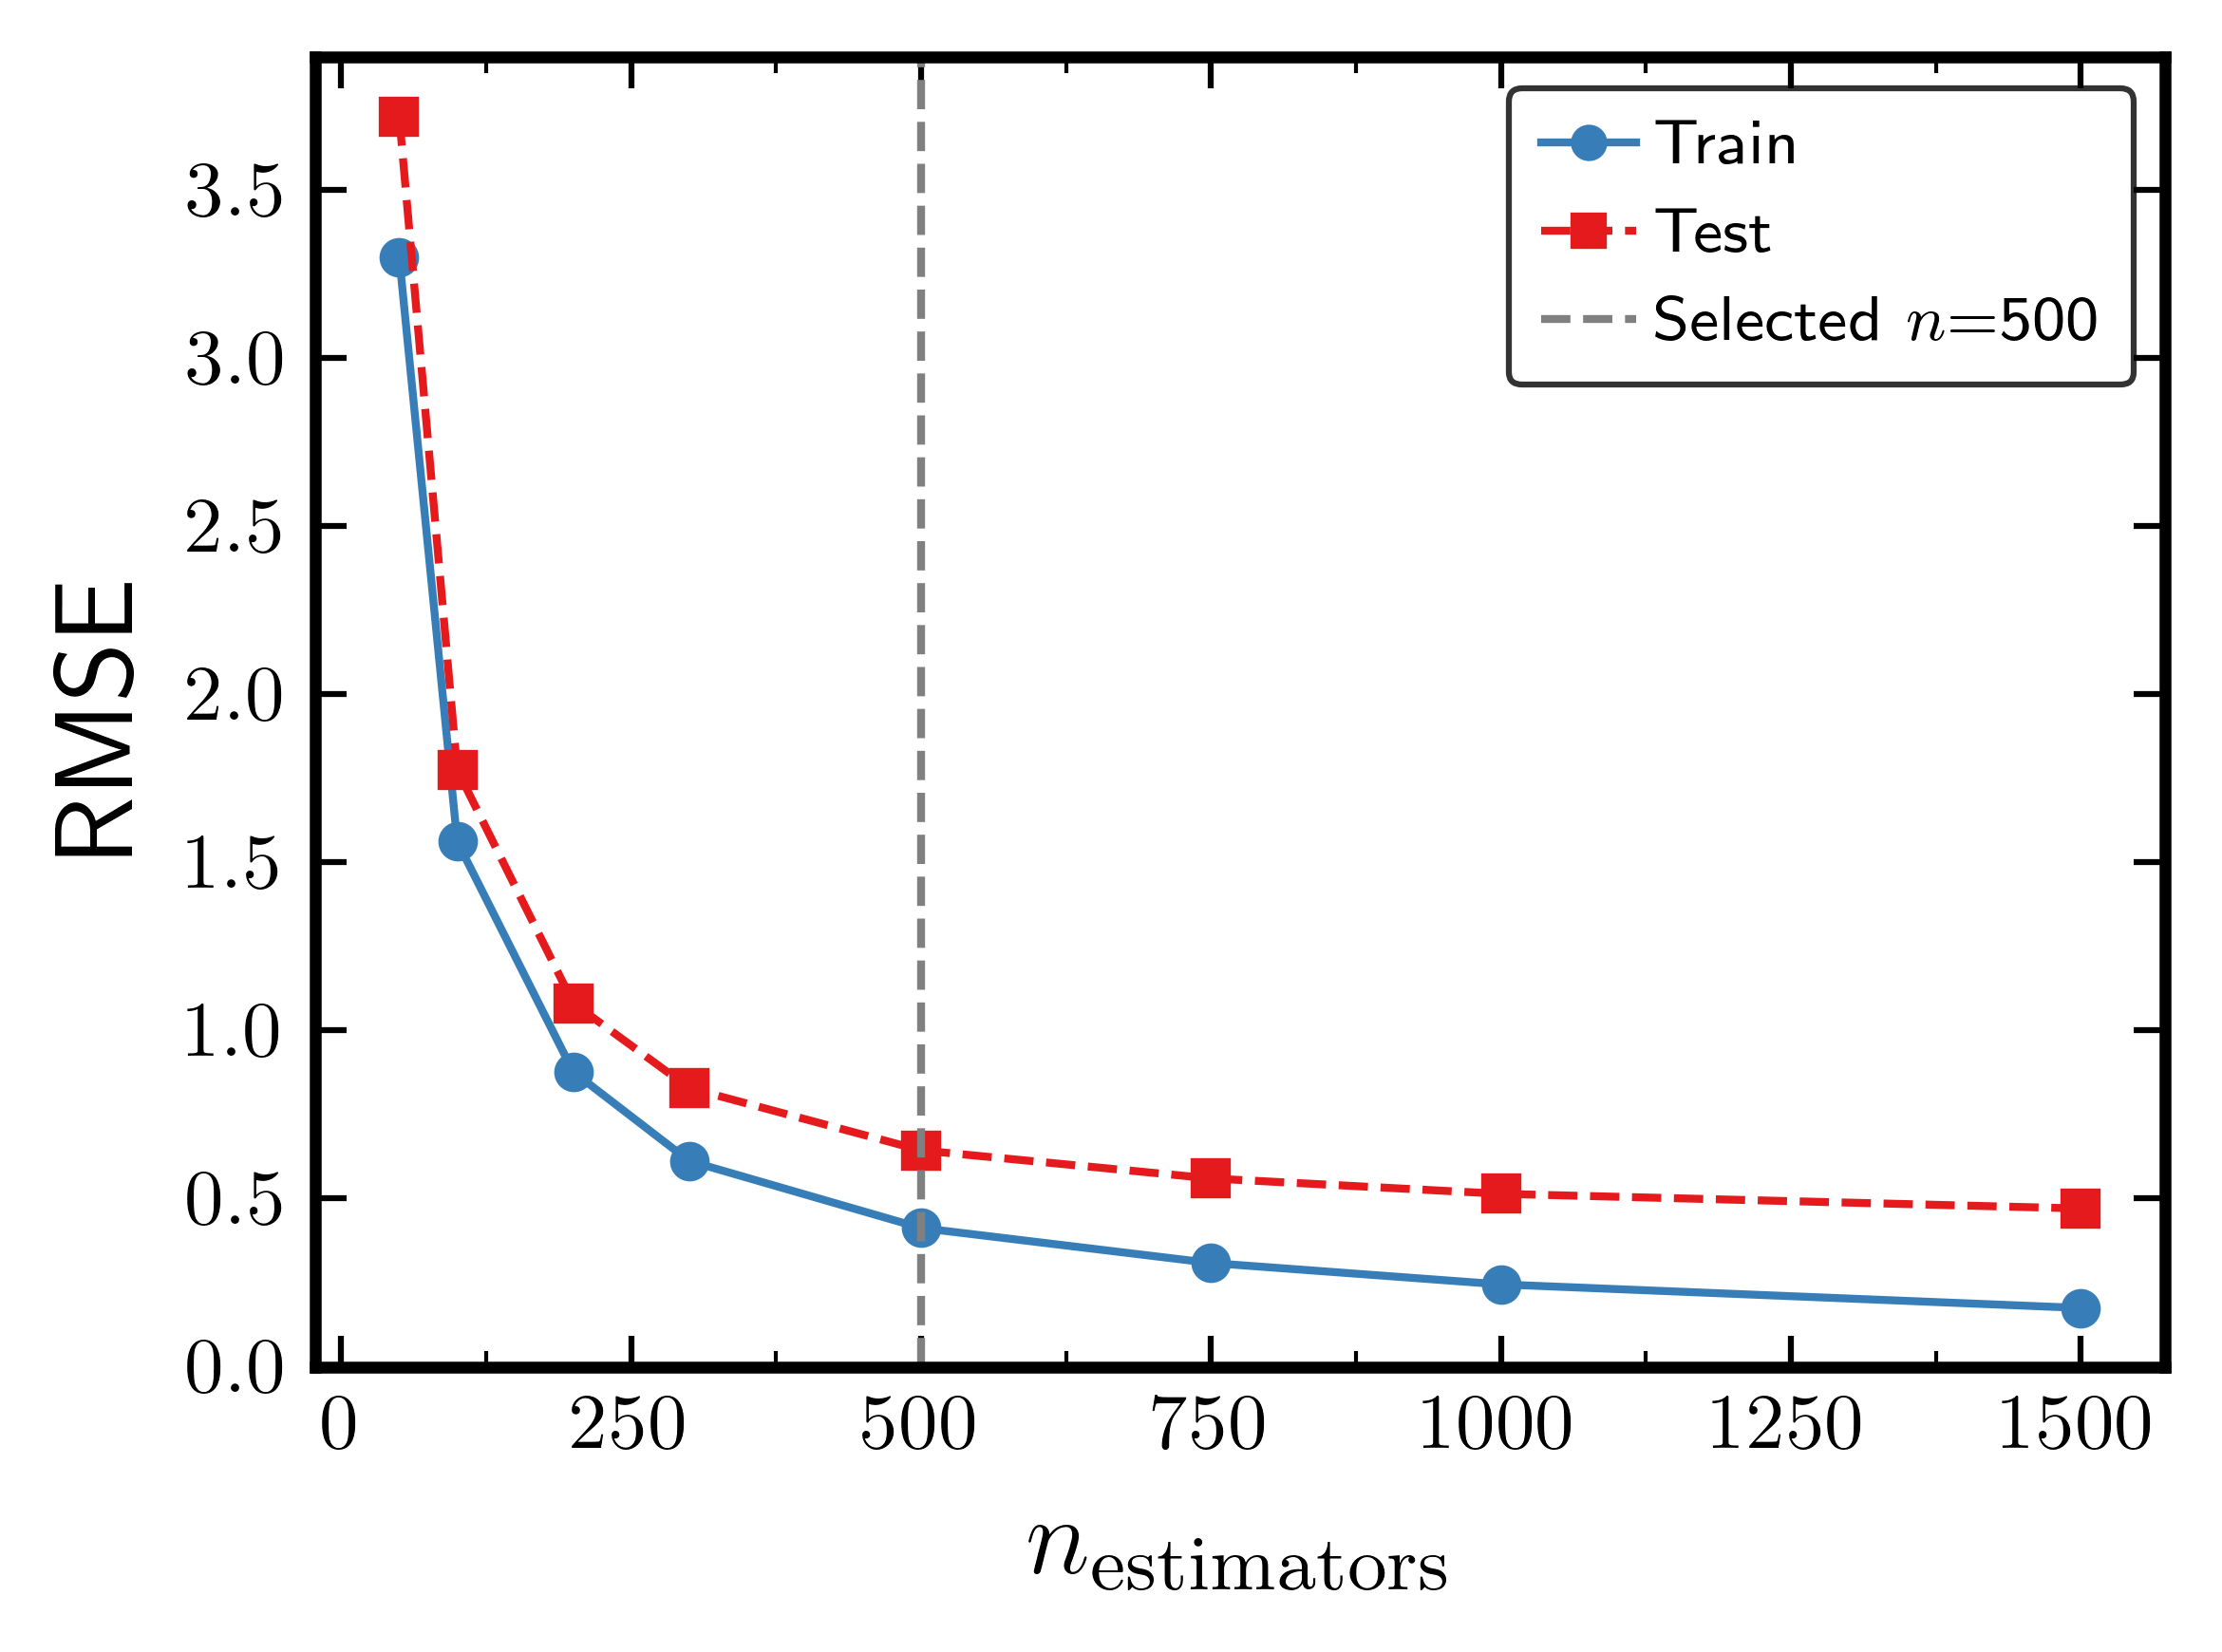

Saved: XGB_P_bubble_n_estimators_sweep


In [9]:
# Hyperparameter analysis: n_estimators sensitivity sweep (XGBoost)
n_est_values = [50, 100, 200, 300, 500, 750, 1000, 1500]

train_rmse_n, test_rmse_n = [], []
for _n in n_est_values:
    _xgb = XGBRegressor(
        n_estimators=_n,
        max_depth=xgb_model.max_depth,
        learning_rate=xgb_model.learning_rate,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_n.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_n.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
print("n_estimators sweep complete.")
for _n, tr, te in zip(n_est_values, train_rmse_n, test_rmse_n):
    print(f"  n_est={_n:>5} | Train RMSE={tr:.4f}  Test RMSE={te:.4f}")

fig, ax = ps.plot_init()
ax.plot(n_est_values, train_rmse_n, marker="o", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[2], label="Train")
ax.plot(n_est_values, test_rmse_n,  marker="s", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[0], label="Test")
ax.axvline(xgb_model.n_estimators, ls="--", color="gray",
           lw=ps.linewidth, label=f"Selected $n$={xgb_model.n_estimators}")
ax.set_xlabel(r"$n_{\mathrm{estimators}}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax, loc="upper right")
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_n_estimators_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_n_estimators_sweep")

max_depth sweep complete.
  depth=2 | Train RMSE=2.4569  Test RMSE=2.7509
  depth=3 | Train RMSE=1.4137  Test RMSE=1.5023
  depth=4 | Train RMSE=0.8820  Test RMSE=1.0051
  depth=5 | Train RMSE=0.5866  Test RMSE=0.7446
  depth=6 | Train RMSE=0.4123  Test RMSE=0.6433
  depth=7 | Train RMSE=0.2986  Test RMSE=0.6207
  depth=8 | Train RMSE=0.2120  Test RMSE=0.6554
  depth=10 | Train RMSE=0.0992  Test RMSE=0.6708


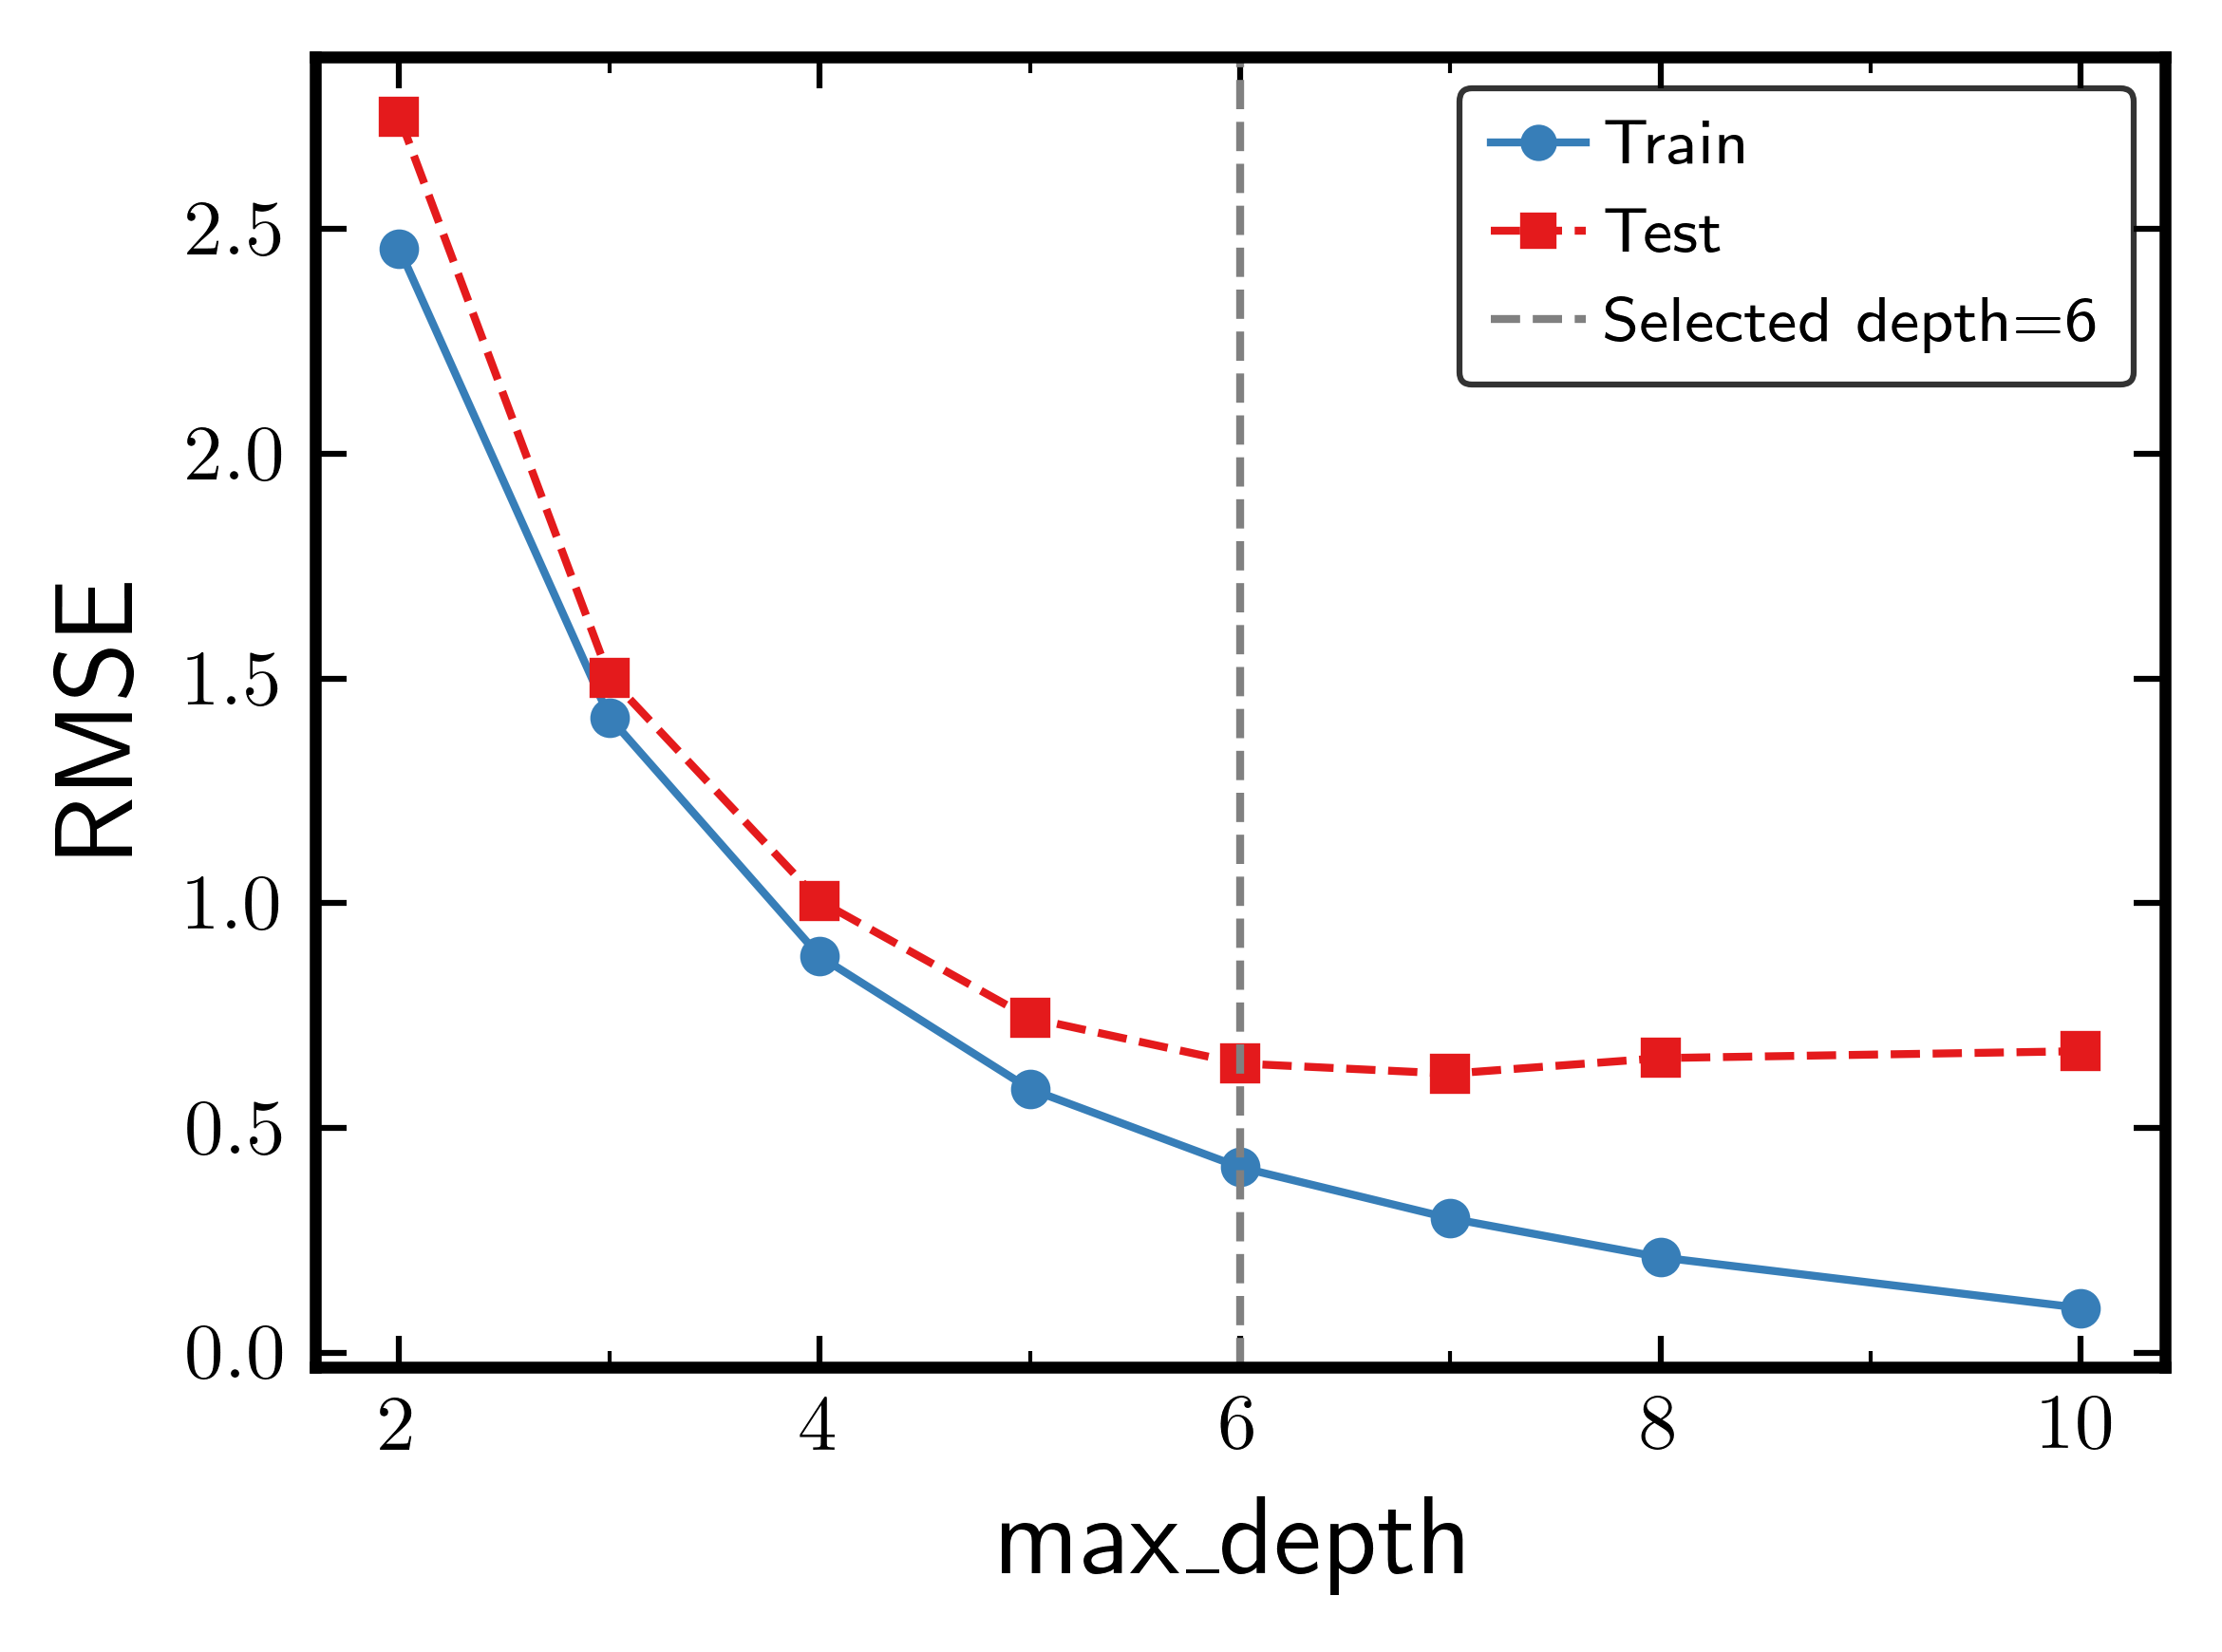

Saved: XGB_P_bubble_max_depth_sweep


In [10]:
# Hyperparameter analysis: max_depth sensitivity sweep (XGBoost)
depth_values = [2, 3, 4, 5, 6, 7, 8, 10]

train_rmse_d, test_rmse_d = [], []
for _d in depth_values:
    _xgb = XGBRegressor(
        n_estimators=xgb_model.n_estimators,
        max_depth=_d,
        learning_rate=xgb_model.learning_rate,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_d.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_d.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
print("max_depth sweep complete.")
for _d, tr, te in zip(depth_values, train_rmse_d, test_rmse_d):
    print(f"  depth={_d} | Train RMSE={tr:.4f}  Test RMSE={te:.4f}")

fig, ax = ps.plot_init()
ax.plot(depth_values, train_rmse_d, marker="o", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[2], label="Train")
ax.plot(depth_values, test_rmse_d,  marker="s", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[0], label="Test")
ax.axvline(xgb_model.max_depth, ls="--", color="gray",
           lw=ps.linewidth, label=f"Selected depth={xgb_model.max_depth}")
ax.set_xlabel(r"max\_depth", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax, loc="upper right")
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_max_depth_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_max_depth_sweep")

learning_rate sweep complete.
  lr=0.001 | Train RMSE=13.6100  Test RMSE=14.2760
  lr=0.005 | Train RMSE=3.1426  Test RMSE=3.5107
  lr=0.010 | Train RMSE=1.4405  Test RMSE=1.6600
  lr=0.050 | Train RMSE=0.4123  Test RMSE=0.6433
  lr=0.100 | Train RMSE=0.2788  Test RMSE=0.5576
  lr=0.200 | Train RMSE=0.1722  Test RMSE=0.4608
  lr=0.300 | Train RMSE=0.1364  Test RMSE=0.5201
  lr=0.500 | Train RMSE=0.1063  Test RMSE=0.5567


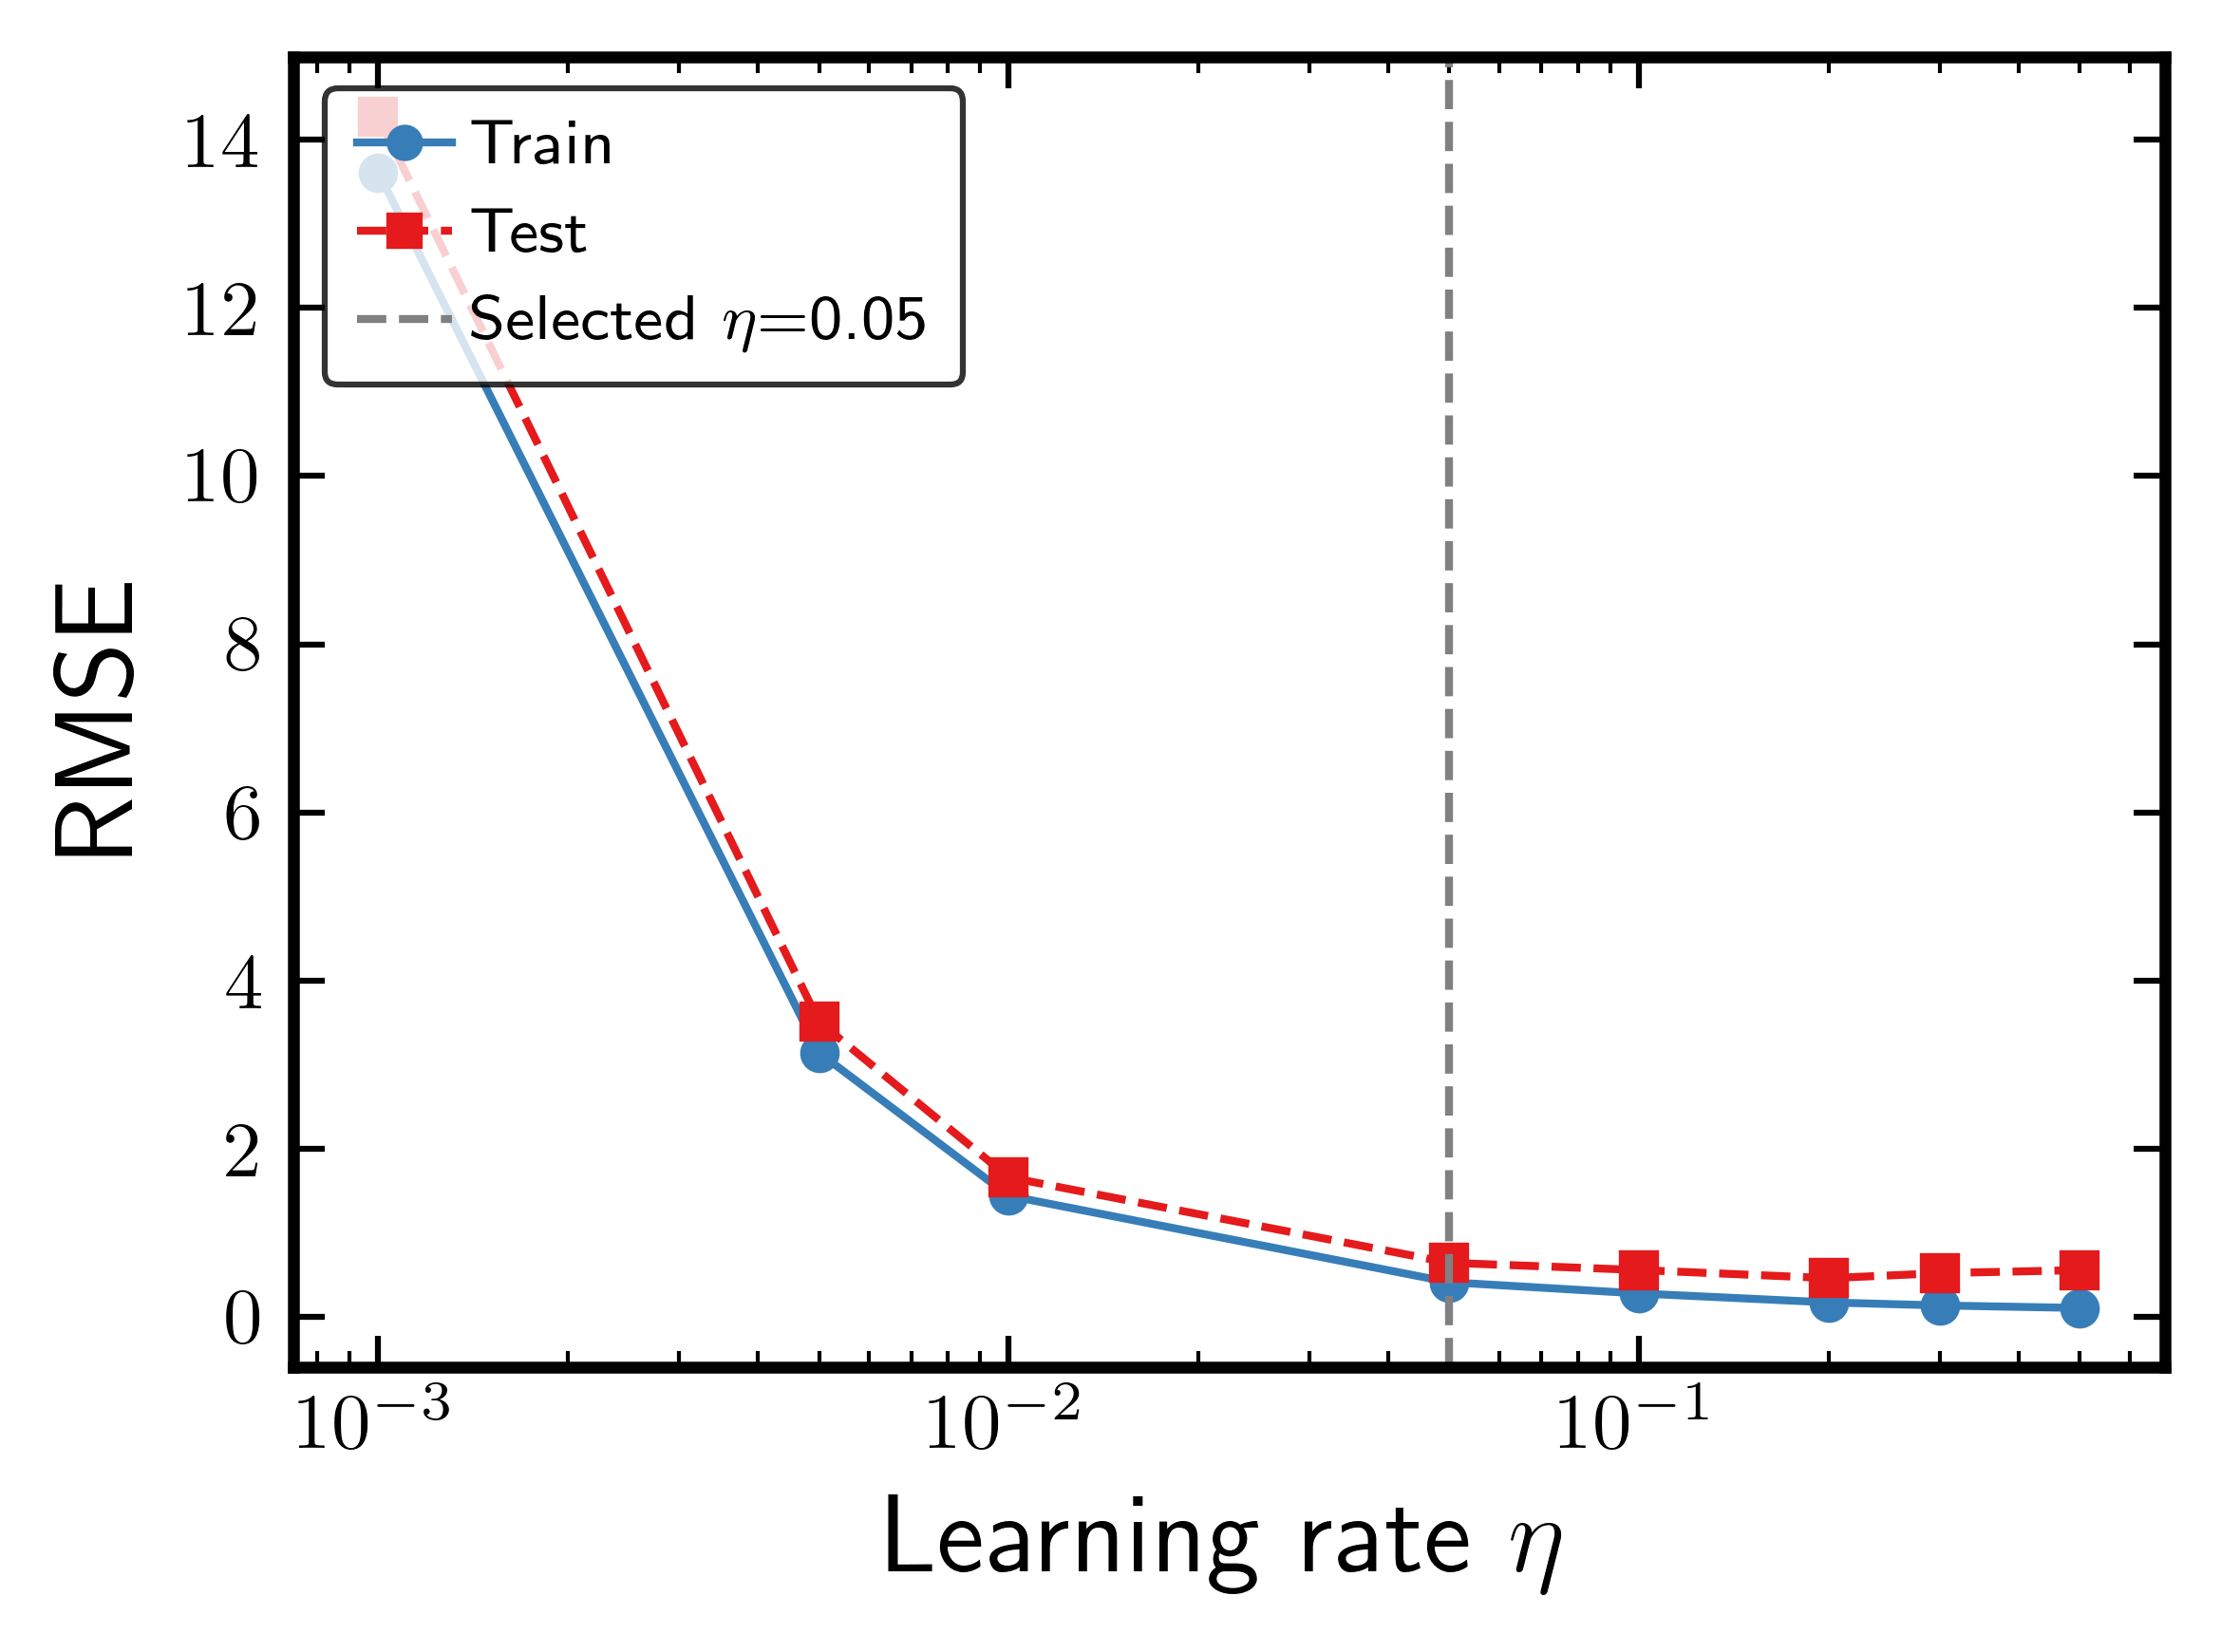

Saved: XGB_P_bubble_learning_rate_sweep


In [11]:
# Hyperparameter analysis: learning_rate sensitivity sweep (XGBoost)
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

train_rmse_lr, test_rmse_lr = [], []
for _lr in lr_values:
    _xgb = XGBRegressor(
        n_estimators=xgb_model.n_estimators,
        max_depth=xgb_model.max_depth,
        learning_rate=_lr,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_lr.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_lr.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
print("learning_rate sweep complete.")
for _lr, tr, te in zip(lr_values, train_rmse_lr, test_rmse_lr):
    print(f"  lr={_lr:.3f} | Train RMSE={tr:.4f}  Test RMSE={te:.4f}")

fig, ax = ps.plot_init()
ax.semilogx(lr_values, train_rmse_lr, marker="o", markersize=ps.markersize,
            lw=ps.linewidth, color=ps.colors[2], label="Train")
ax.semilogx(lr_values, test_rmse_lr,  marker="s", markersize=ps.markersize,
            lw=ps.linewidth, color=ps.colors[0], label="Test")
ax.axvline(xgb_model.learning_rate, ls="--", color="gray",
           lw=ps.linewidth, label=rf"Selected $\eta$={xgb_model.learning_rate}")
ax.set_xlabel(r"Learning rate $\eta$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(LogLocator(subs="auto"))
ps.style_legend(ax, loc="upper left")
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_learning_rate_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_learning_rate_sweep")

Outlier threshold (3σ): ±1.335500
Test outliers: 92/2904 (3.17%)
Val  outliers: 69/2905  (2.38%)
Saved: XGB_P_bubble_outliers.csv (161 rows)
  idx split  source_id  temperature  pressure     actual  predicted  residual
17152  test         88        250.0 39.822086  49.748103  48.291519  1.456584
 7748  test         40        200.0  7.242061  44.016768  41.867310  2.149458
 9684  test         50        200.0 55.556597 121.635785 117.703354  3.932431
 8146  test         42        205.0 15.605196 112.571014 114.381729 -1.810715
17161  test         88        255.0 39.130737  51.784384  49.477661  2.306723
15388  test         79        245.0 31.732476  83.231246  79.965561  3.265685
 7396  test         38        215.0 51.264248  74.168619  75.818314 -1.649695
 4648  test         24        205.0 23.629725  94.263072  91.039932  3.223140
15332  test         79        215.0  5.517150 110.062042 111.612892 -1.550850
15416  test         79        260.0 27.103718  79.136069  80.795967 -1.659898
1

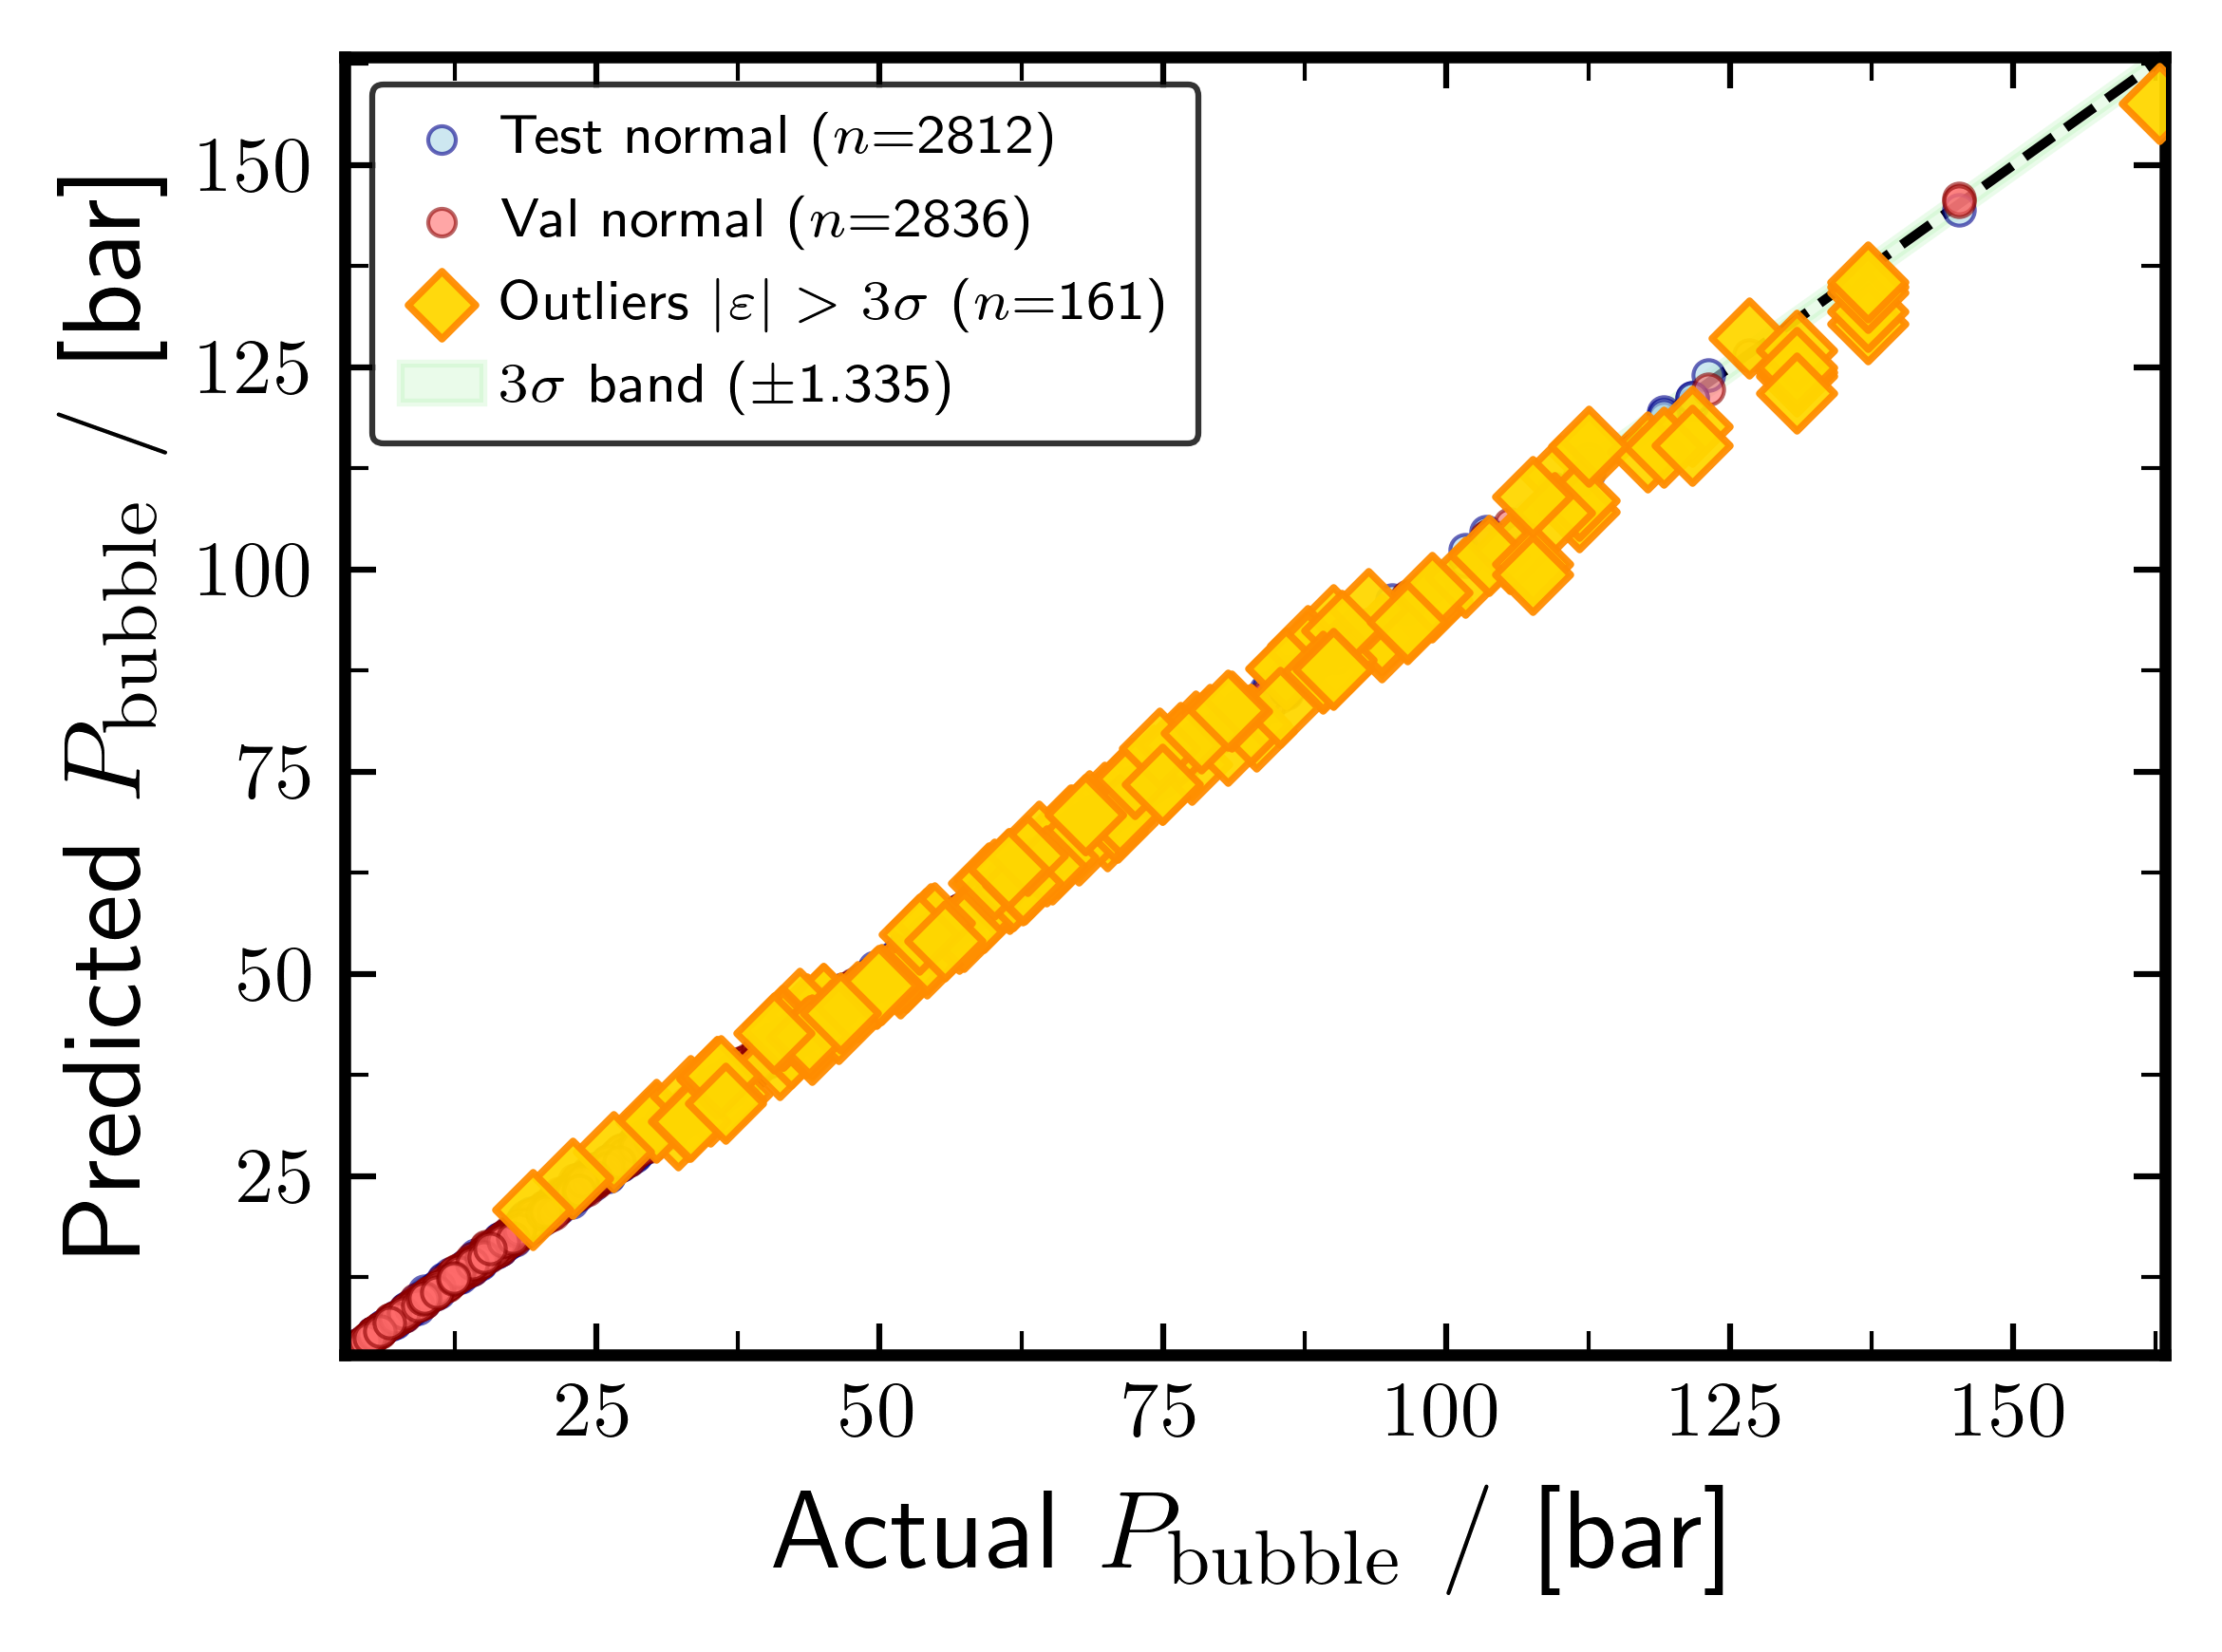

Saved: XGB_P_bubble_outlier_parity


In [12]:
# Outlier flagging: test + val samples where |residual| > 3 * global std
all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3σ): ±{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"XGB_{target}_outliers.csv"), index=False)
print(f"Saved: XGB_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=45, facecolors="gold", edgecolors="darkorange",
        linewidths=0.9, marker="D", zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_outlier_parity")

In [13]:
# XGBoost Feature Importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=list(df[features].columns)
).sort_values(ascending=False)

print("\nXGBoost Feature Importance (gain):")
print(xgb_importance.to_string())


XGBoost Feature Importance (gain):
z_hydrogen            0.412819
pressure              0.328921
temperature           0.121050
z_carbon dioxide      0.051750
z_hydrogen sulfide    0.026382
z_nitrogen            0.020460
z_methane             0.017628
z_argon               0.010677
z_carbon monoxide     0.006418
z_oxygen              0.003894


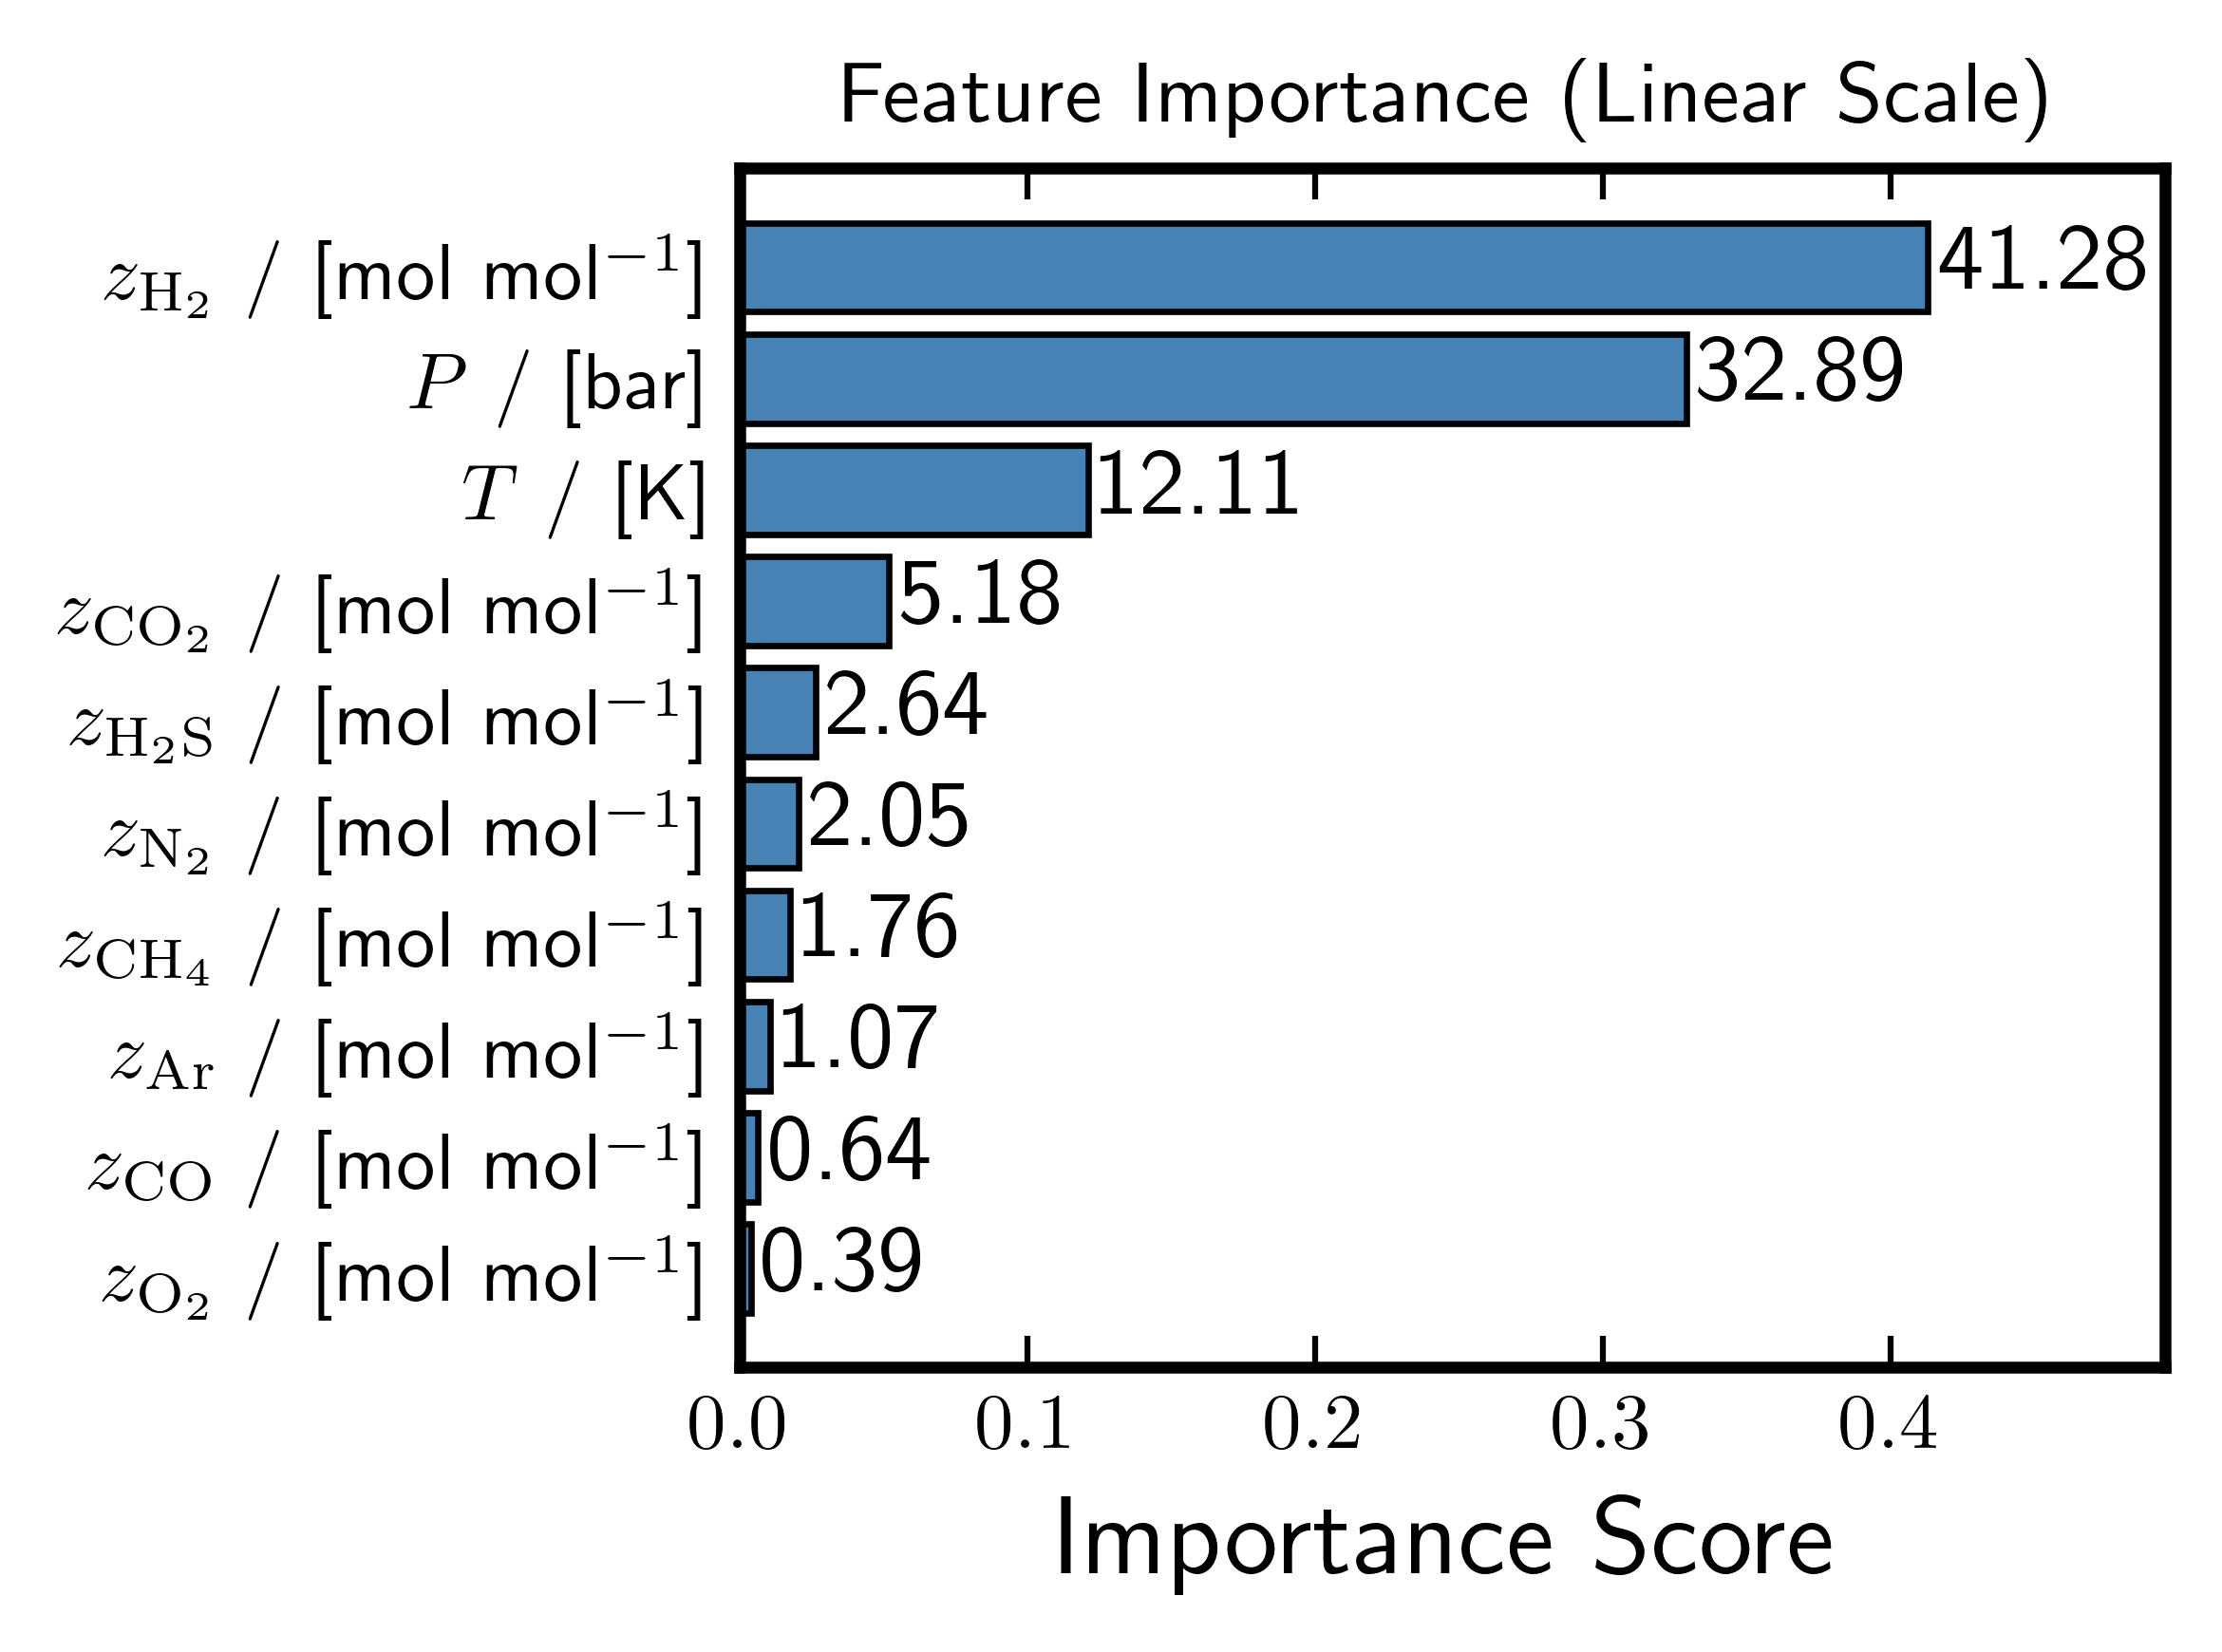

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [14]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_importances=xgb_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="XGB_P_bubble_feature_importance_linear", folder=OUTPUT_FOLDER)

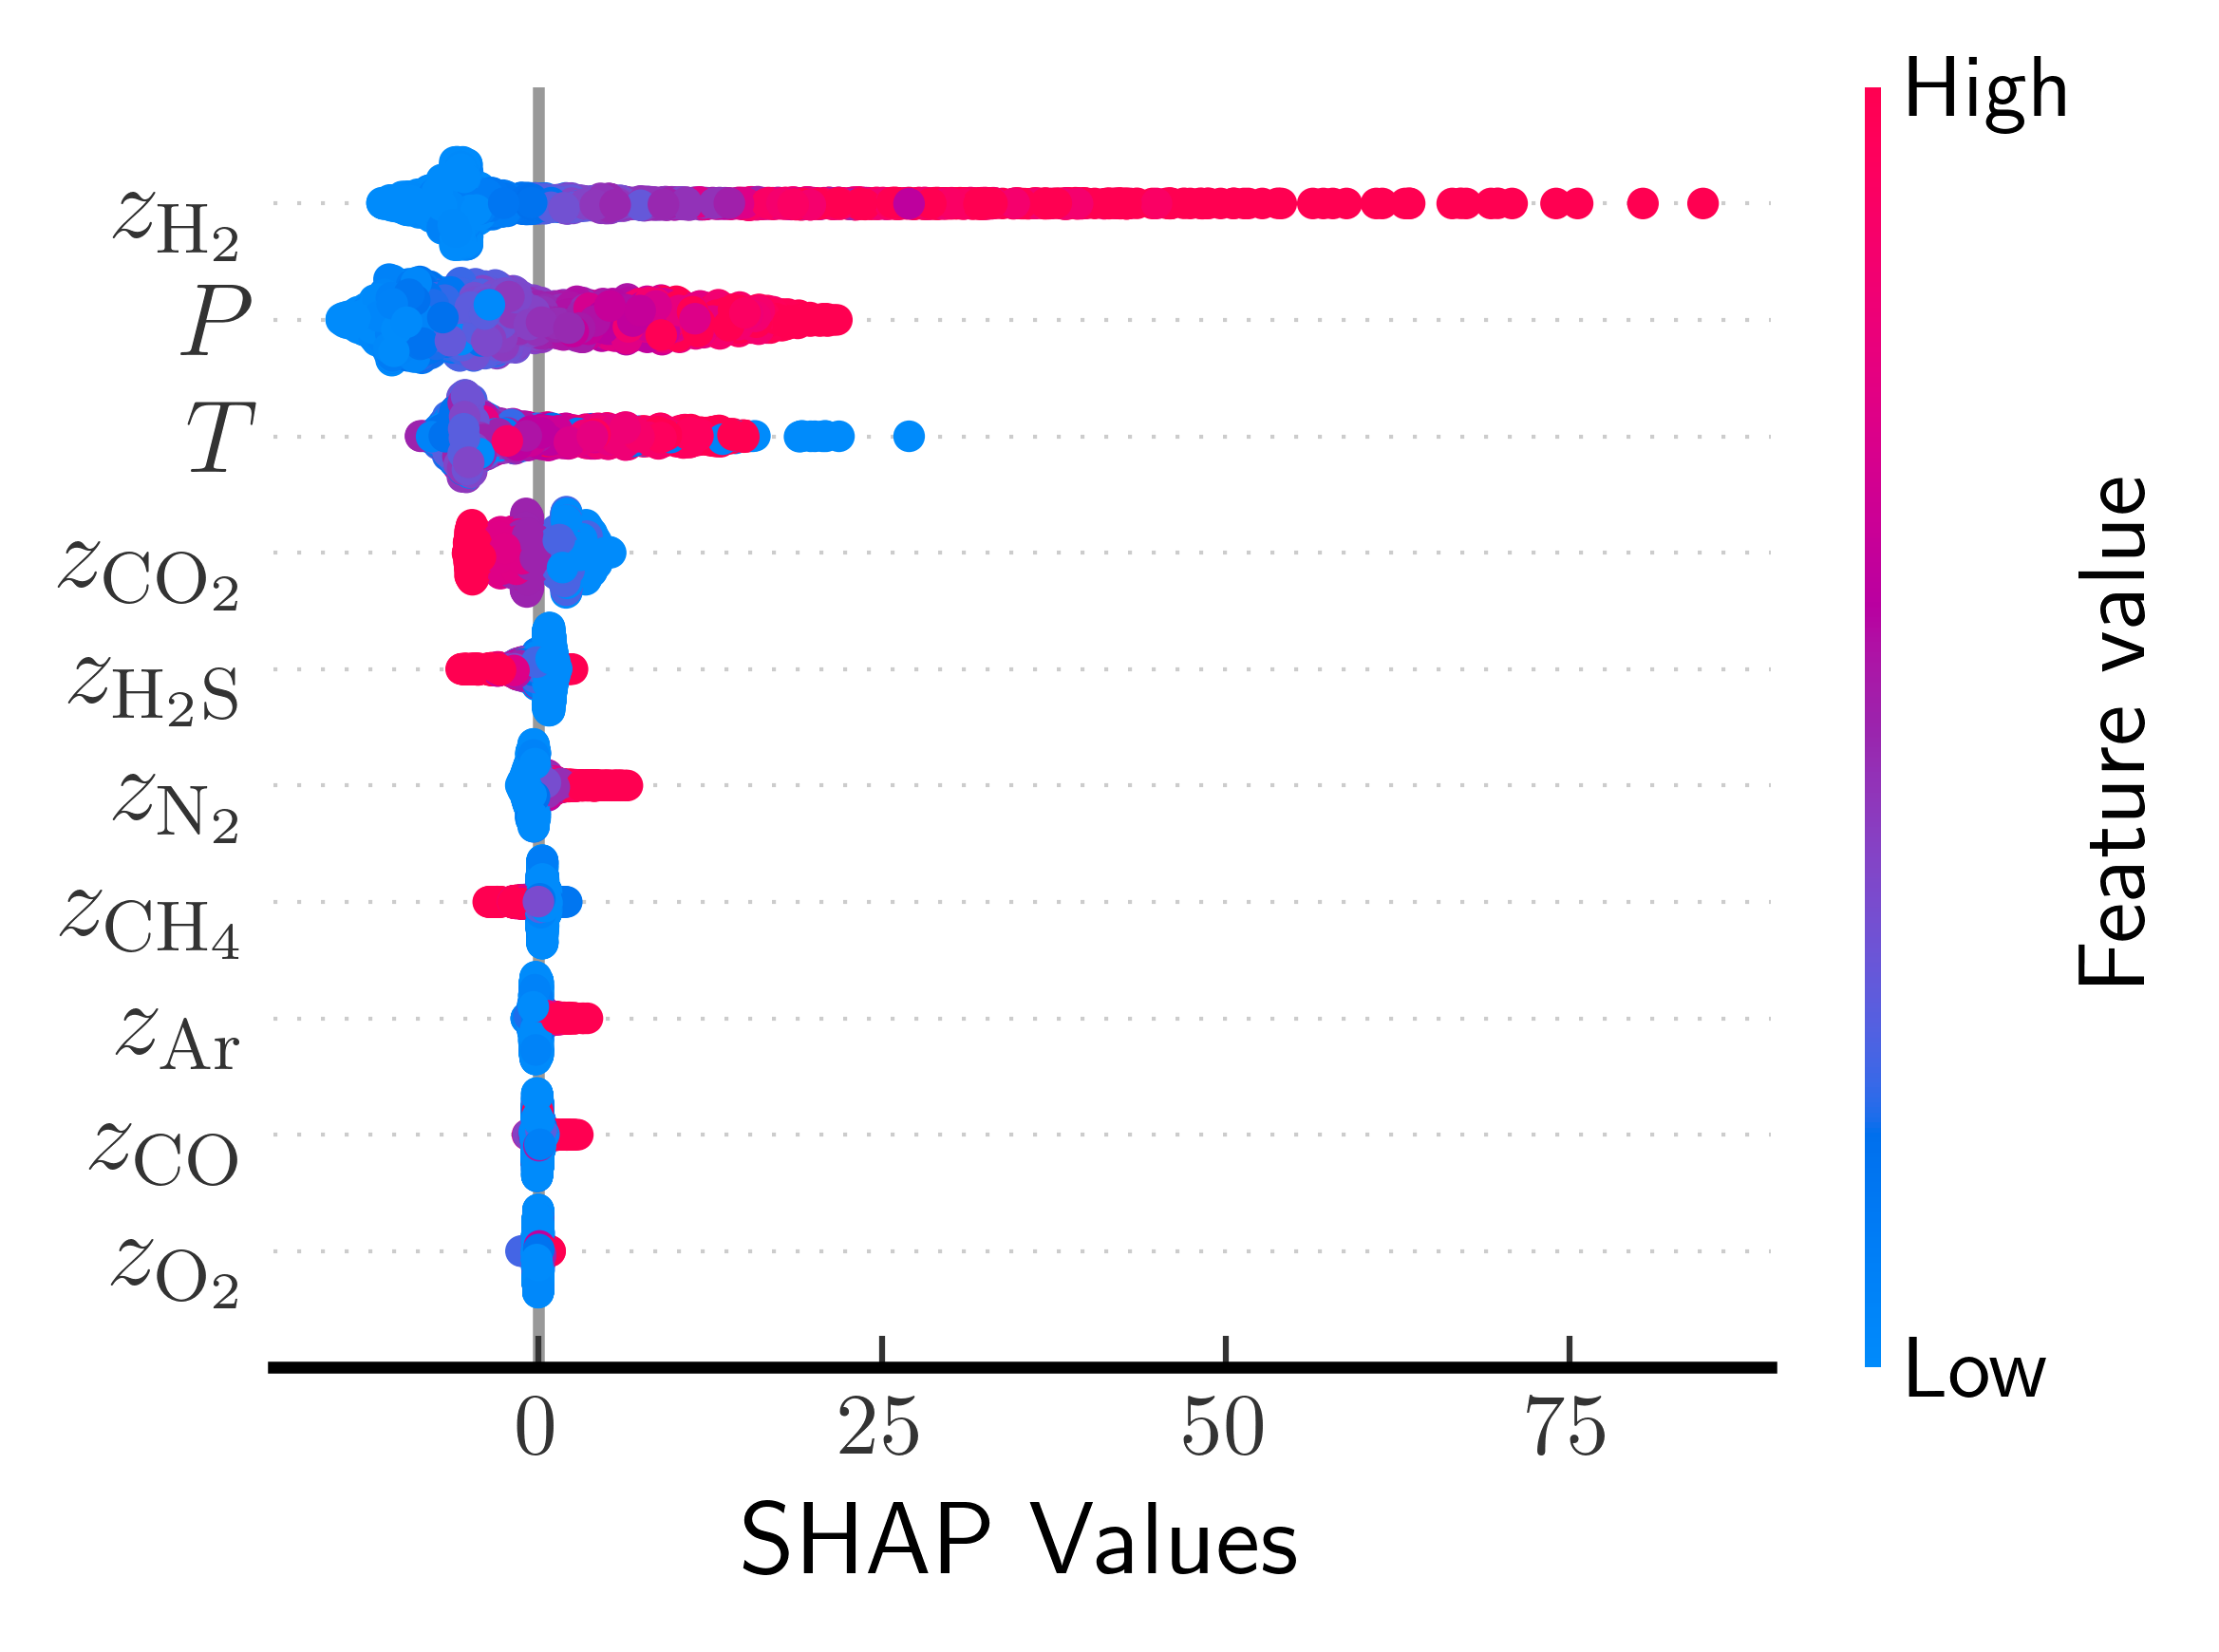

In [15]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "P_bubble": r"$P_{\mathrm{bubble}}$",
}

# SHAP Values — XGBoost
explainer   = shap.TreeExplainer(xgb_model)       
shap_values = explainer.shap_values(X_test)         

feature_labels = [label_map.get(f, f) for f in features]
shap_df = pd.DataFrame(shap_values, columns=feature_labels)

# Plot 1: Beeswarm Summary
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_labels,
    show=False,
    plot_size=None)
ax = plt.gca()
ax.set_xlabel("SHAP Values")
plt.tight_layout()
ps.save_plot(fig, "XGB_P_bubble_shap_summary")
plt.show()

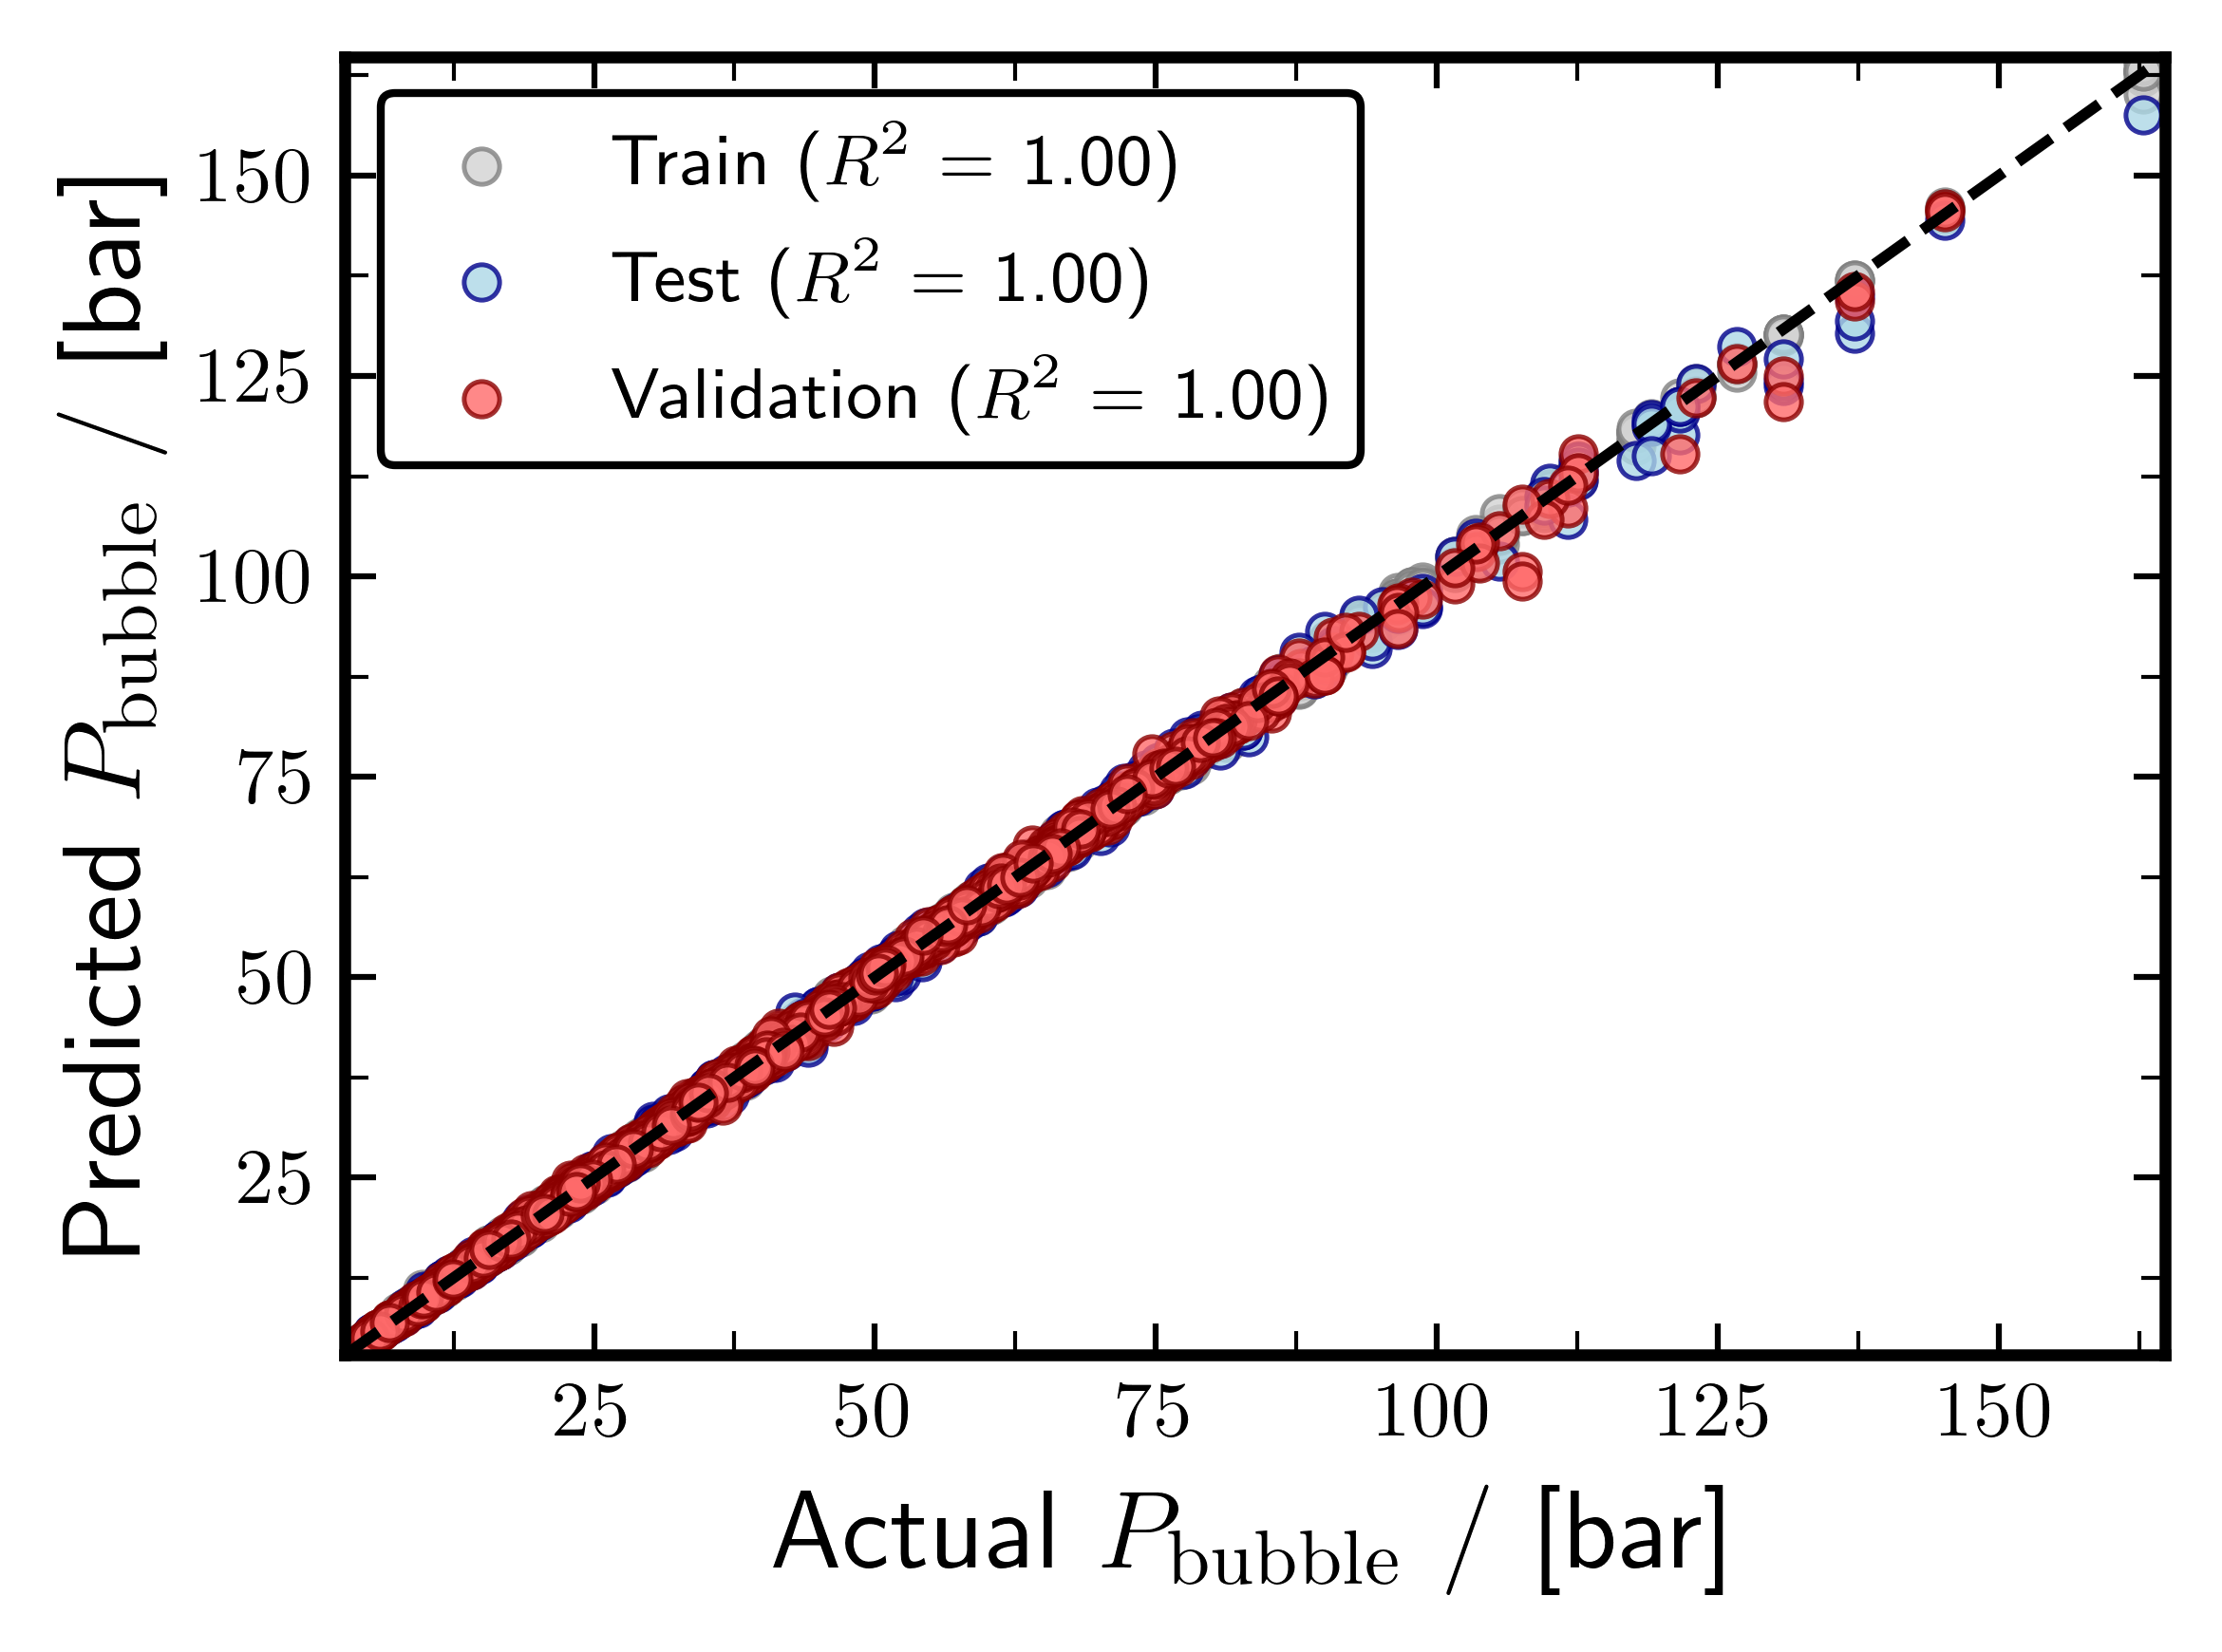

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]'>)

In [16]:
# Parity plot
post.plot_parity(model_name="XGBoost", save_path="XGB_P_bubble_parity_plot", folder=OUTPUT_FOLDER)

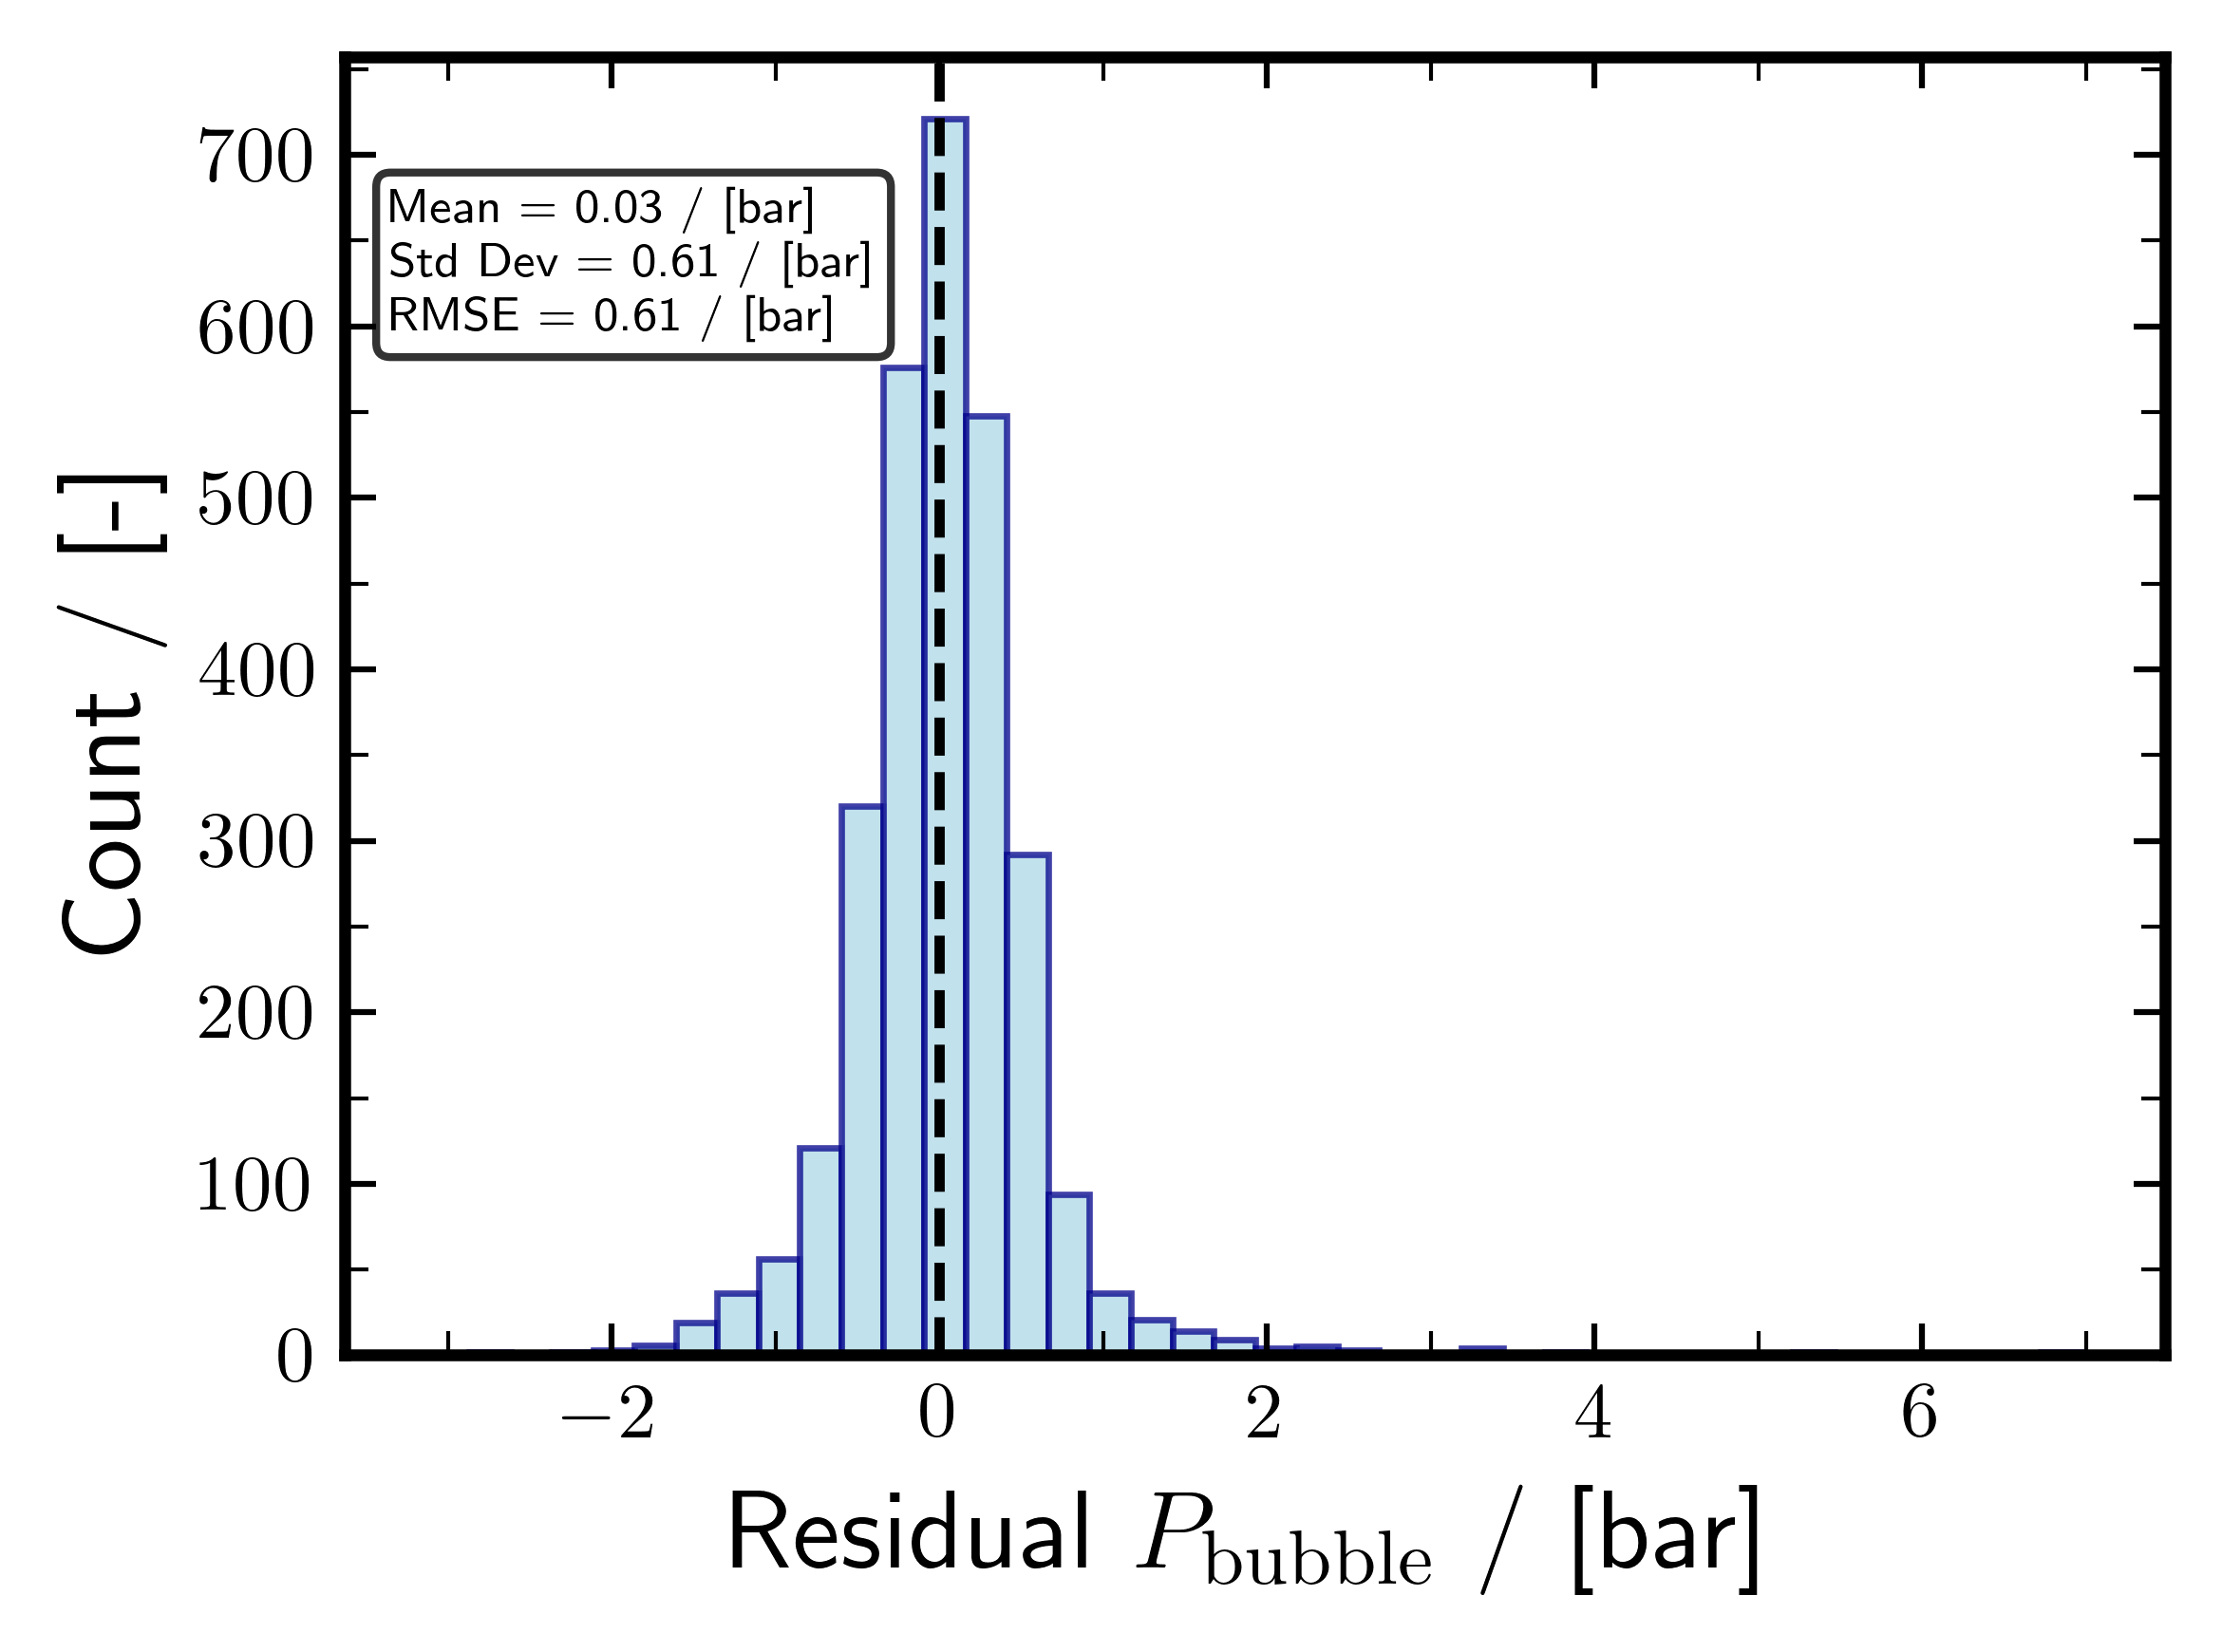

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Count / [-]'>)

In [17]:
# Residual distribution
post.plot_residual_distribution(save_path="XGB_P_bubble_residual_distribution", folder=OUTPUT_FOLDER)

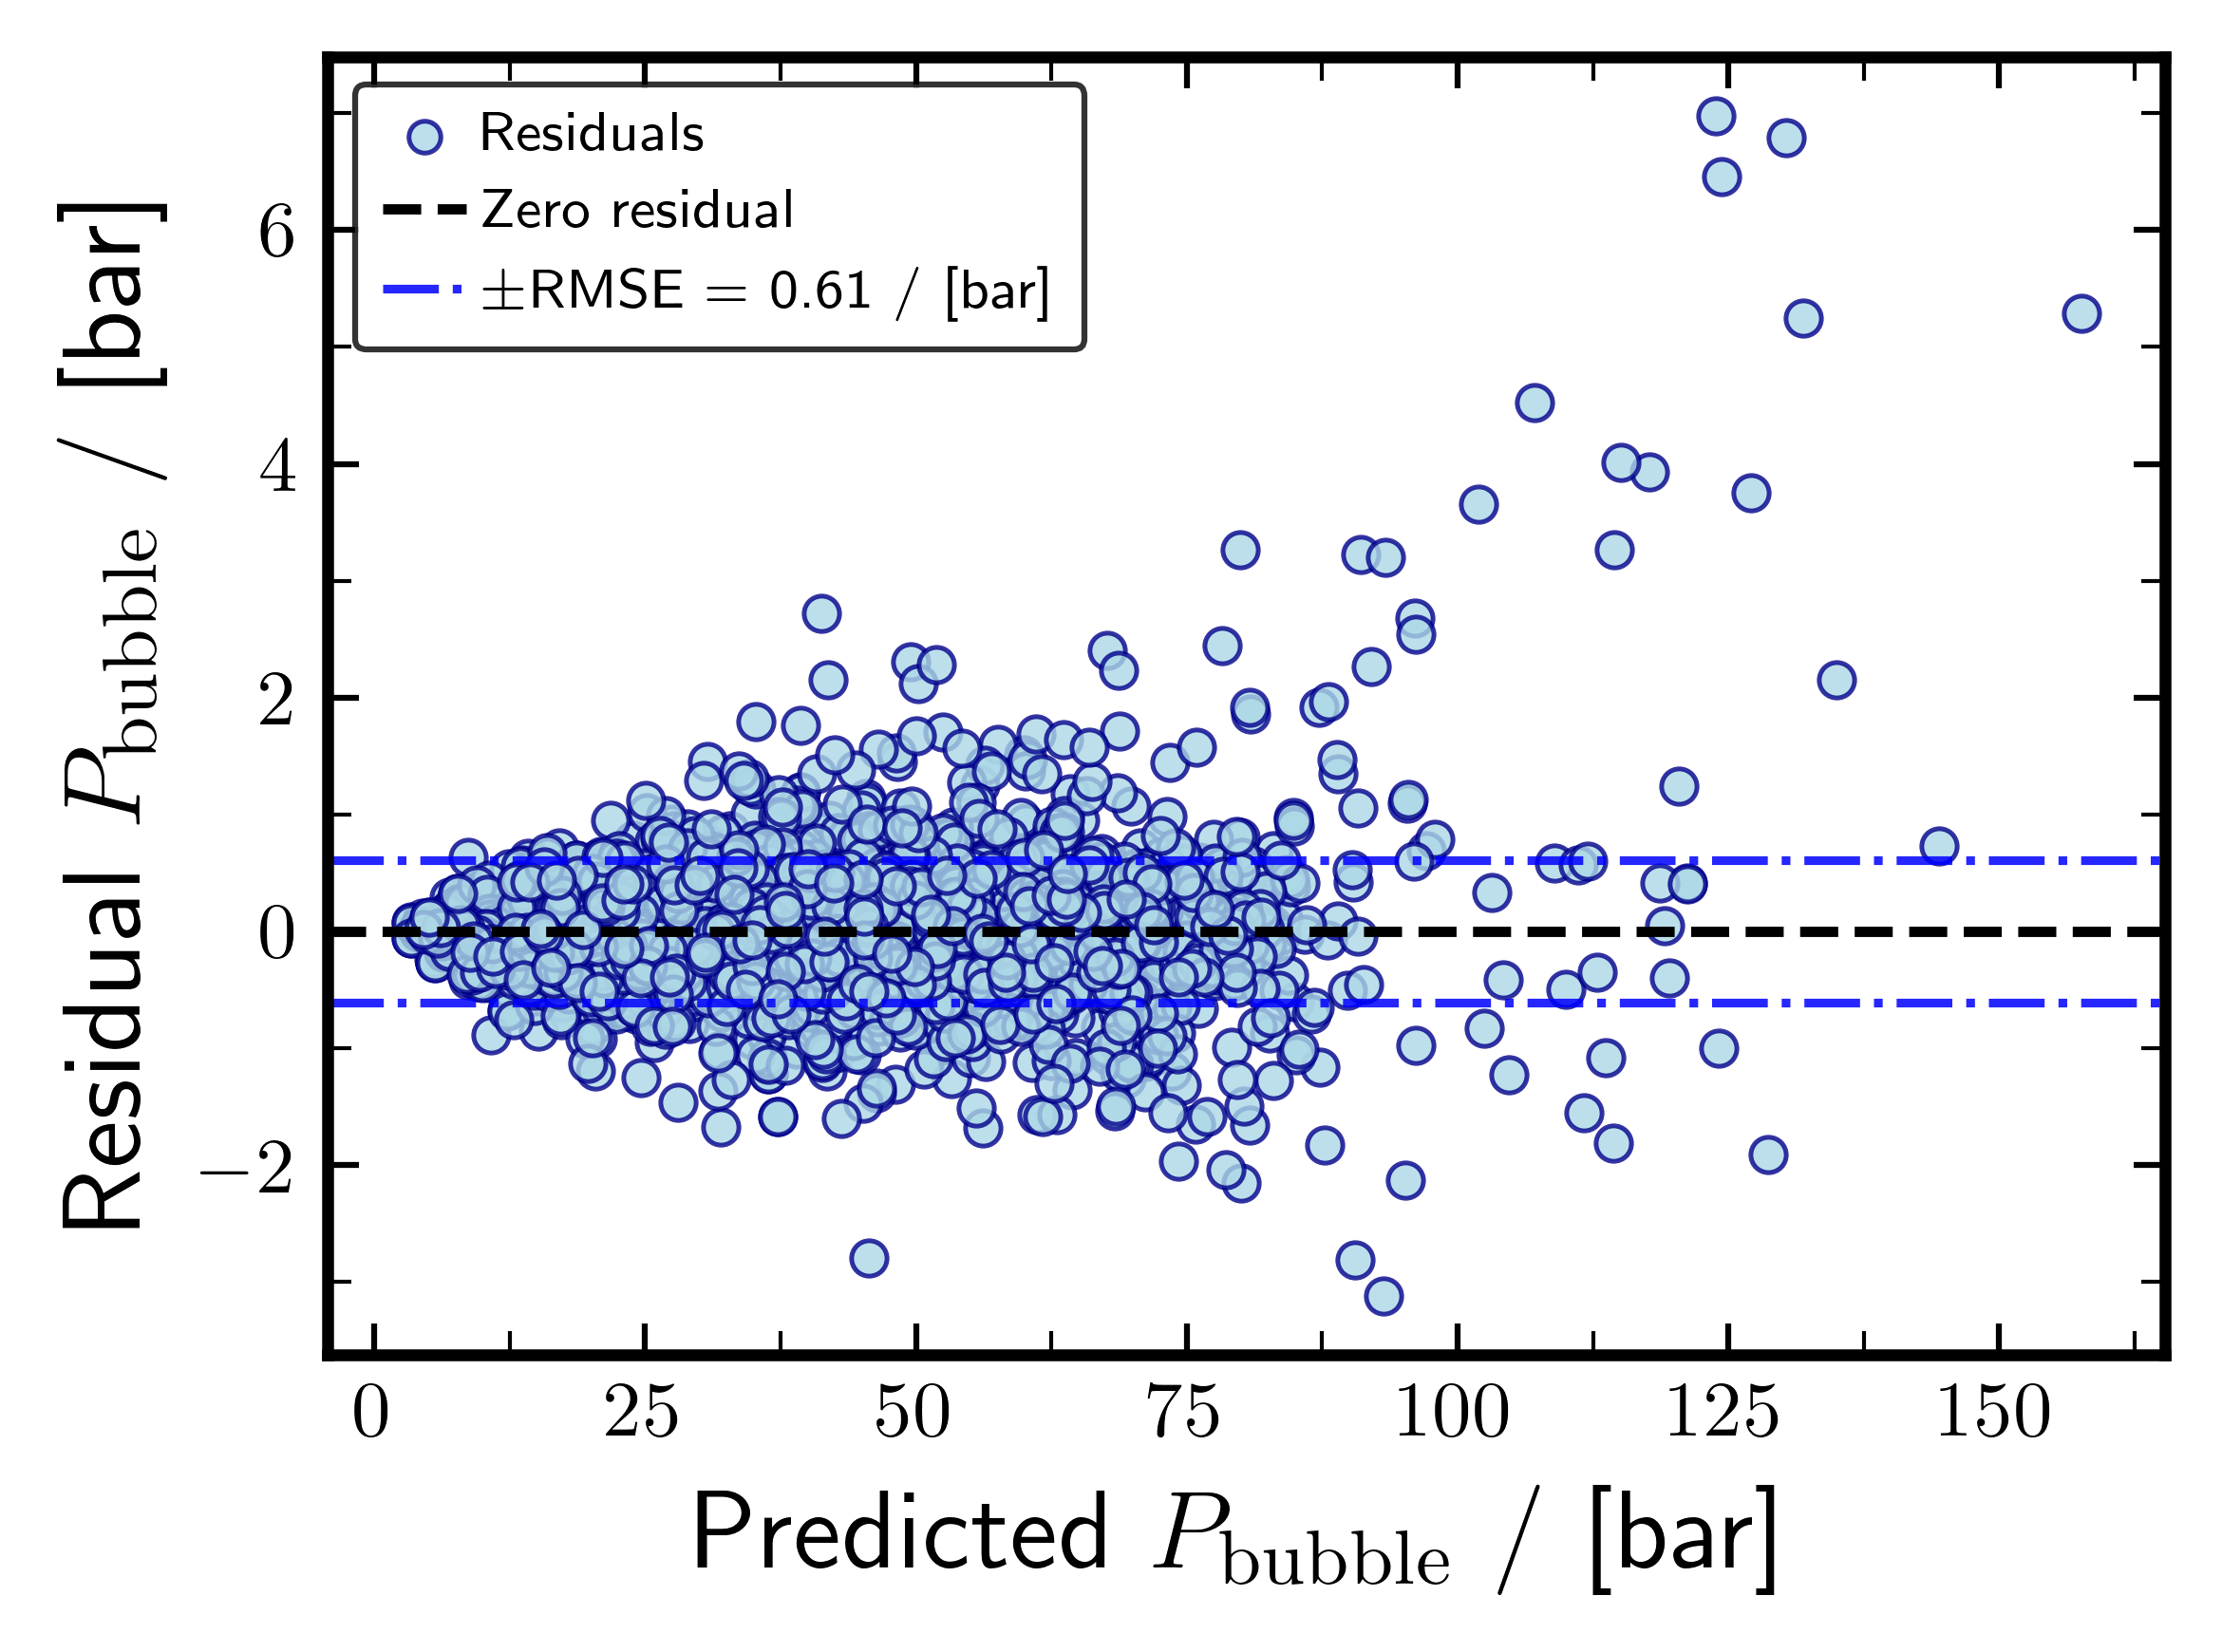

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Residual $P_{\\mathrm{bubble}}$ / [bar]'>)

In [18]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="XGB_P_bubble_residual_vs_predicted", folder=OUTPUT_FOLDER)

In [19]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["cv_mape_scores"]  = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]    = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]     = float(cv_mape_scores.std() * 100)
metrics["n_est_sweep_values"]     = n_est_values
metrics["n_est_sweep_test_rmse"]  = test_rmse_n
metrics["depth_sweep_values"]     = depth_values
metrics["depth_sweep_test_rmse"]  = test_rmse_d
metrics["lr_sweep_values"]        = lr_values
metrics["lr_sweep_test_rmse"]     = test_rmse_lr
metrics["model"]           = "XGBoost"
metrics["n_estimators"]    = xgb_model.n_estimators
metrics["max_depth"]       = xgb_model.max_depth
metrics["learning_rate"]   = xgb_model.learning_rate
metrics["subsample"]       = xgb_model.subsample
metrics["colsample_bytree"]= xgb_model.colsample_bytree
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"XGB_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        2904
R² Score:       0.999225
RMSE:           0.609136
MAE:            0.388419
Mean Residual:  0.028551
Std Residual:   0.608467

FEATURE IMPORTANCES:
------------------------------------------------------------
  z_hydrogen                |  41.28% | ████████████████████
  pressure                  |  32.89% | ████████████████
  temperature               |  12.11% | ██████
  z_carbon dioxide          |   5.18% | ██
  z_hydrogen sulfide        |   2.64% | █
  z_nitrogen                |   2.05% | █
  z_methane                 |   1.76% | 
  z_argon                   |   1.07% | 
  z_carbon monoxide         |   0.64% | 
  z_oxygen                  |   0.39% | 

Metrics saved to: SLURM_Pbubble/XGB_P_bubble_metrics.json


In [20]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.89 minutes
